In [4]:
# Run-all configuration flags
RUN_ITERATIVE_ANALOG_LOOP = True  # set True to run the optional iterative expansion+docking cell


RBP4 ligand workflow (current iteration): receptor-centered docking setup, pharmacophore-aware GATv2 screening, structural analog generation, hosted Vina docking, PubChem/OpenFDA enrichment, and final analog-level triaging with an explicit **all-trans retinol benchmark**. The workflow is tuned for laptop execution while preserving reproducibility and interpretable outputs.

In [5]:
#!pip install torch torchvision torchaudio 
#!pip install torch_geometric
#!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
#!pip install meeko pandas numpy tqdm scikit-learn matplotlib requests biopython

In [6]:
#"""!pip install gemmi prody

### Notebook Inputs and Outputs (current)

This notebook is self-contained and operates directly on project folders.

- `data/known_binders.smi`: positive training set for few-shot learning
- `data/Enamine_FDA_approved_Drugs_plated_1123cmpds_20250601.smiles`: screening library
- `data/5NU7_receptor.pdbqt` and `data/5NU7_retinol.pdb`: receptor and binding-site reference
- `models/rbp4_gnn.pt` (+ optional ensemble checkpoints): trained model artifacts
- `outputs/enamine1123_scored.csv`: parent-library scores
- `outputs/enamine1123_top5.csv` and `outputs/enamine1123_top5_analogs.csv`: selected parents and generated analogs
- `outputs/docking/docking_best_pose_per_ligand.csv`: best docking affinities (parents, analogs, retinol reference)
- `outputs/final_candidates_tiered.csv` and `outputs/final_candidates_tiered_ensemble.csv`: final analog-level triage tables

In [7]:
# get_receptor.py
import os
import sys
import subprocess
from pathlib import Path

import requests


def download_and_prepare_rbp4(pdb_id="5NU7", output_dir="data"):
    """
    Download 5NU7 (holo-RBP4 + retinol at 1.5 A) and prepare receptor PDBQT.
    Returns the receptor PDBQT path.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1) Download raw PDB and fail fast on HTTP errors.
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    raw_pdb = output_dir / f"{pdb_id}_raw.pdb"
    raw_pdb.write_text(r.text, encoding="utf-8")
    print(f"Downloaded {pdb_id} -> {raw_pdb}")

    # 2) Save retinol ligand (RTL) for binding-site center estimation.
    retinol_pdb = output_dir / f"{pdb_id}_retinol.pdb"
    with raw_pdb.open("r", encoding="utf-8") as fin, retinol_pdb.open("w", encoding="utf-8") as fout:
        for line in fin:
            if line.startswith("HETATM") and "RTL" in line:
                fout.write(line)
    print(f"Saved retinol ligand -> {retinol_pdb}")

    # 3) Keep only protein ATOM records.
    clean_pdb = output_dir / f"{pdb_id}_protein.pdb"
    with raw_pdb.open("r", encoding="utf-8") as fin, clean_pdb.open("w", encoding="utf-8") as fout:
        for line in fin:
            if line.startswith("ATOM"):
                fout.write(line)
    print(f"Saved cleaned protein -> {clean_pdb}")

    # 4) Prepare receptor PDBQT using Meeko via module invocation.
    # Meeko 0.7+: `-i/--read_with_prody` requires ProDy (often painful on Windows).
    # Use `--read_pdb` instead. `-o` is an output *basename* (no .pdbqt suffix);
    # `-p/--write_pdbqt` then writes "<basename>.pdbqt" for the rigid receptor.
    pdbqt_out = output_dir / f"{pdb_id}_receptor.pdbqt"
    out_basename = str(output_dir / f"{pdb_id}_receptor")
    cmd = [
        sys.executable,
        "-m",
        "meeko.cli.mk_prepare_receptor",
        "--read_pdb",
        str(clean_pdb),
        "-o",
        out_basename,
        "-p",
        "-a",  # --allow_bad_res
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError(
            "Meeko receptor preparation failed.\n"
            f"Command: {' '.join(cmd)}\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    if not pdbqt_out.exists():
        alts = sorted(output_dir.glob(f"{pdb_id}_receptor*.pdbqt"))
        extra = f" Other PDBQT matches: {alts}" if alts else ""
        raise FileNotFoundError(f"Expected receptor PDBQT was not created: {pdbqt_out}.{extra}")

    print(f"Receptor PDBQT ready -> {pdbqt_out}")
    return str(pdbqt_out)


def get_binding_site_center(retinol_pdb_path: str) -> list:
    """Compute binding-site center from RTL coordinates in the PDB file."""
    coords = []
    with open(retinol_pdb_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("HETATM"):
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                coords.append([x, y, z])

    if not coords:
        # Fallback center for 5NU7 binding cavity.
        print("No RTL coordinates found; using fallback center for 5NU7")
        return [19.5, 6.2, 14.8]

    cx = sum(c[0] for c in coords) / len(coords)
    cy = sum(c[1] for c in coords) / len(coords)
    cz = sum(c[2] for c in coords) / len(coords)
    center = [round(cx, 2), round(cy, 2), round(cz, 2)]
    print(f"Binding-site center (RTL centroid): {center}")
    return center


if __name__ == "__main__":
    pdbqt = download_and_prepare_rbp4()
    center = get_binding_site_center("data/5NU7_retinol.pdb")
    print(f"\nUse this in docking config:\n  binding_center = {center}")

Downloaded 5NU7 -> data\5NU7_raw.pdb
Saved retinol ligand -> data\5NU7_retinol.pdb
Saved cleaned protein -> data\5NU7_protein.pdb
Receptor PDBQT ready -> data\5NU7_receptor.pdbqt
Binding-site center (RTL centroid): [13.8, 7.68, 0.51]

Use this in docking config:
  binding_center = [13.8, 7.68, 0.51]


In [5]:
# mol_graph.py — RBP4 pharmacophore-aware featurization
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from torch_geometric.data import Data

# ── Standard atom features ──────────────────────────────────────────────
ATOM_TYPES  = ['C','N','O','S','F','P','Cl','Br','I','Other']
DEGREES     = list(range(6))
CHARGES     = [-2,-1,0,1,2]
HYBRIDIZE   = [Chem.HybridizationType.SP,
               Chem.HybridizationType.SP2,
               Chem.HybridizationType.SP3,
               Chem.HybridizationType.SP3D,
               Chem.HybridizationType.SP3D2]
H_COUNTS    = list(range(5))
CHIRALITY   = [Chem.ChiralType.CHI_UNSPECIFIED,
               Chem.ChiralType.CHI_TETRAHEDRAL_CW,
               Chem.ChiralType.CHI_TETRAHEDRAL_CCW]

def get_rbp4_pharmacophore_features(mol, atom_idx: int) -> list:
    """
    4 extra RBP4-specific pharmacophore features per atom.
    
    Based on the A1120 co-crystal structure (PDB 3FMZ) showing:
    - Carboxylate anchors to Arg121 via salt bridge  ^3^ 
    - Carbonyl accepts H-bond from Leu37 backbone NH  ^3^   
    - Hydrophobic aryl/cyclohexyl fills deep β-barrel pocket  ^3^ 
    - CF3/halogen occupies the deep hydrophobic sub-pocket  ^3^ 
    """
    atom = mol.GetAtomWithIdx(atom_idx)
    
    # Feature 1: Is this atom part of a carboxylate/carboxylic acid?
    # (key anchor for Arg121 salt bridge)
    is_carboxylate = 0
    if atom.GetAtomicNum() == 6:  # Carbon
        neighbors = [n.GetAtomicNum() for n in atom.GetNeighbors()]
        o_count = neighbors.count(8)
        if o_count >= 2:
            is_carboxylate = 1
    elif atom.GetAtomicNum() == 8:
        for nbr in atom.GetNeighbors():
            if nbr.GetAtomicNum() == 6:
                o_on_c = sum(1 for n in nbr.GetNeighbors() if n.GetAtomicNum() == 8)
                if o_on_c >= 2:
                    is_carboxylate = 1

    # Feature 2: Is this atom in an aromatic ring?
    # (phenyl/pyridyl fills hydrophobic pocket like retinol's β-ionone ring)
    is_aromatic_ring = int(atom.GetIsAromatic())

    # Feature 3: Is this atom part of a cyclohexyl/aliphatic ring?
    # (mimics β-ionone ring of retinol buried in deep pocket)
    is_aliphatic_ring = int(atom.IsInRing() and not atom.GetIsAromatic())

    # Feature 4: Is this a halogen or CF3-bearing carbon?
    # (halogens occupy the deep hydrophobic sub-pocket, key for A1120-type binders)
    is_halogen_or_cf3 = int(atom.GetAtomicNum() in [9, 17, 35, 53])  # F, Cl, Br, I

    return [is_carboxylate, is_aromatic_ring, is_aliphatic_ring, is_halogen_or_cf3]

def get_atom_features(mol, atom) -> np.ndarray:
    """36 standard + 4 RBP4-specific = 40-dimensional node features."""
    sym = atom.GetSymbol()
    atom_oh  = [int(sym == t) for t in ATOM_TYPES[:-1]] + [int(sym not in ATOM_TYPES[:-1])]
    deg_oh   = [int(atom.GetDegree() == d) for d in DEGREES]
    chg_oh   = [int(atom.GetFormalCharge() == c) for c in CHARGES]
    hyb_oh   = [int(atom.GetHybridization() == h) for h in HYBRIDIZE]
    arom     = [int(atom.GetIsAromatic())]
    h_oh     = [int(atom.GetTotalNumHs() == h) for h in H_COUNTS]
    ring     = [int(atom.IsInRing())]
    chir_oh  = [int(atom.GetChiralTag() == c) for c in CHIRALITY]
    rbp4_ph  = get_rbp4_pharmacophore_features(mol, atom.GetIdx())
    
    return np.array(
        atom_oh + deg_oh + chg_oh + hyb_oh + arom + h_oh + ring + chir_oh + rbp4_ph,
        dtype=np.float32
    )  # shape: (40,)

def get_bond_features(bond) -> np.ndarray:
    """10-dimensional bond features."""
    bt = bond.GetBondType()
    bt_oh = [int(bt == Chem.BondType.SINGLE),
             int(bt == Chem.BondType.DOUBLE),
             int(bt == Chem.BondType.TRIPLE),
             int(bt == Chem.BondType.AROMATIC)]
    conj  = [int(bond.GetIsConjugated())]
    ring  = [int(bond.IsInRing())]
    st    = bond.GetStereo()
    st_oh = [int(st == Chem.BondStereo.STEREONONE),
             int(st == Chem.BondStereo.STEREOZ),
             int(st == Chem.BondStereo.STEREOE),
             int(st == Chem.BondStereo.STEREOANY)]
    return np.array(bt_oh + conj + ring + st_oh, dtype=np.float32)  # (10,)

def mol_to_graph(smiles: str, label: float = None) -> Data | None:
    """Convert SMILES → PyTorch Geometric Data object with RBP4-aware features."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    node_feats = np.stack([get_atom_features(mol, a) for a in mol.GetAtoms()])
    x = torch.tensor(node_feats, dtype=torch.float)

    edge_idx, edge_feats = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = get_bond_features(bond)
        edge_idx  += [[i, j], [j, i]]
        edge_feats += [bf, bf]

    if len(edge_idx) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 10), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(np.array(edge_feats), dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=smiles)
    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)
    return data

c:\Users\kylea\miniconda3\envs\rbp4_gnn\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\kylea\miniconda3\envs\rbp4_gnn\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\kylea\miniconda3\envs\rbp4_gnn\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\kylea\miniconda3\envs\rbp4_gnn\Lib\site-packages\torch_sparse\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\kylea\miniconda3\envs\rbp4_gnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# gnn_model.py
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_add_pool

class RBP4GATv2(torch.nn.Module):
    """
    GATv2 classifier tuned for RBP4 binding prediction.
    
    Input: 40-dim node features (36 standard + 4 RBP4 pharmacophore)
    Output: scalar logit → sigmoid → P(RBP4 binder)
    
    Architecture informed by:
    - RBP4 β-barrel hydrophobic cavity  ^1^  ^3^ 
    - Non-retinoid binder SAR (A1120 series)  ^3^ 
    - GATv2 dynamic attention mechanism  ^10^ 
    """
    def __init__(self,
                 num_node_features: int = 40,   # 36 + 4 RBP4-specific
                 num_edge_features: int = 10,
                 hidden_dim: int = 96,
                 num_heads: int = 6,
                 dropout: float = 0.3):
        super().__init__()

        # Message Passing Layers
        self.conv1 = GATv2Conv(num_node_features, hidden_dim,
                               heads=num_heads, concat=True,
                               dropout=dropout, edge_dim=num_edge_features)
        self.conv2 = GATv2Conv(hidden_dim * num_heads, hidden_dim,
                               heads=num_heads, concat=True,
                               dropout=dropout, edge_dim=num_edge_features)
        self.conv3 = GATv2Conv(hidden_dim * num_heads, hidden_dim,
                               heads=num_heads, concat=False,
                               dropout=dropout, edge_dim=num_edge_features)

        # Batch Normalization
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim * num_heads)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim * num_heads)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim)

        # MLP Head — predicts RBP4 binding probability
        self.fc1     = torch.nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2     = torch.nn.Linear(hidden_dim // 2, 1)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_attr=edge_attr)))
        x = F.elu(self.bn2(self.conv2(x, edge_index, edge_attr=edge_attr)))
        x = F.elu(self.bn3(self.conv3(x, edge_index, edge_attr=edge_attr)))
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.fc1(x))
        return self.fc2(x)

    def get_embedding(self, data) -> torch.Tensor:
        """Return graph-level embedding (before MLP head) for prototypical scoring."""
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_attr=edge_attr)))
        x = F.elu(self.bn2(self.conv2(x, edge_index, edge_attr=edge_attr)))
        x = F.elu(self.bn3(self.conv3(x, edge_index, edge_attr=edge_attr)))
        return global_mean_pool(x, batch)

    def predict_proba(self, data) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            return torch.sigmoid(self.forward(data)).squeeze(-1)

In [7]:
# train_gnn.py
import torch
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
# mol_graph / gnn_model live in other cells of this notebook (not installable packages).
if "mol_to_graph" not in globals():
    raise RuntimeError("Run the `mol_graph.py` cell above first (defines mol_to_graph).")
if "RBP4GATv2" not in globals():
    raise RuntimeError("Run the `gnn_model.py` cell above first (defines RBP4GATv2).")

# ══════════════════════════════════════════════════════════════════
# Your 12 known/suspected RBP4 binders
KNOWN_BINDERS = [
    "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C",   # All-trans Retinol
    "CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=O)C)C",           # All-trans Retinal
    "CCCCCCCCCCCCCCCC(=O)OC/C=C(\\C)/C=C/C=C(\\C)/C=C/C1=C(C)CCCC1(C)C",  # Retinyl palmitate
    "CC(=Cc1ccc(cc1)C(=O)O)c1ccc2c(c1)C(C)(C)CCC2(C)C",  # EC23
    "C/C(=C\\C=C\\C(=C\\CN)\\C)/C=C/C1=C(C)CCCC1(C)C",   # Retinylamine
    "NCC[C@H](O)C1=CC(OCC2CCC([H])([H])CC2)=CC=C1",       # Octopamine ether
    "NCC[C@H](O)C1=CC(OCC2CCC(F)(F)CC2)=CC=C1",           # Fluorinated ether
    "OC(CC[NH3+])C1=CC(OC(C2CCCCC2)=O)=CC=C1.O=C[O-]",   # Cyclohexyl ester
    "OC(CC[NH3+])C1=CC(OC(C(CC)CC)=O)=CC=C1.O=C[O-]",    # Ethylhexyl ester
    "OC(CC[NH3+])C1=CC(OC(C(CCC)CCC)=O)=CC=C1.O=C[O-]",  # Dipropyl ester
    "C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl",           # Diclofenac
    "C1=CC=C(C(=C1)C(=O)OCCOCCO)NC2=CC=CC(=C2)C(F)(F)F",  # Mefenamic ester
]

# A1120 as an additional positive control (known Ki = 8.3 nM)  ^3^ 
A1120_SMILES = "O=C(N1CCC(CC1)c1ccccc1C(F)(F)F)Nc1ccccc1C(=O)O"

FDA_LIBRARY_PATH = "data/Enamine_FDA_approved_Drugs_plated_1123cmpds_20250601.smiles"
MODEL_SAVE_PATH  = "models/rbp4_gnn.pt"
Path(MODEL_SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
EPOCHS           = 150
LR               = 5e-4
# ══════════════════════════════════════════════════════════════════

def build_rbp4_dataset(known_binders, fda_path):
    """
    Build training set for RBP4 binding prediction.
    
    Positives: 12 known binders + A1120 (confirmed Ki = 8.3 nM)  ^3^ 
    Negatives: FDA drugs as decoys (structurally diverse non-binders)
    
    IMPORTANT: RBP4 binds lipophilic molecules. Good decoys should be
    hydrophilic drugs (antibiotics, antivirals) that are unlikely to
    fit the hydrophobic β-barrel cavity.
    """
    dataset = []
    all_positives = known_binders + [A1120_SMILES]
    
    print(f"Building dataset with {len(all_positives)} positive binders...")
    
    for smi in all_positives:
        # Clean SMILES (remove salt counterions)
        smi_clean = smi.split('.')[0]
        g = mol_to_graph(smi_clean, label=1.0)
        if g:
            dataset.append(g)
    
    # Load FDA library as decoys
    fda_df = pd.read_csv(fda_path, sep='\t')
    if fda_df.shape[1] < 2:
        raise ValueError(f"Expected at least 2 tab-separated columns in {fda_path}")
    fda_df = fda_df.iloc[:, :2].copy()
    fda_df.columns = ['smiles', 'name']
    fda_df['smiles'] = fda_df['smiles'].astype(str).str.strip()
    fda_df['name'] = fda_df['name'].astype(str).str.strip()
    fda_df = fda_df[fda_df['smiles'].str.upper().ne('SMILES')]
    
    n_decoys = min(90, len(fda_df))
    decoys = fda_df.sample(n_decoys, random_state=42)
    
    for _, row in decoys.iterrows():
        g = mol_to_graph(row['smiles'], label=0.0)
        if g is not None:
            dataset.append(g)
    
    n_pos = sum(1 for d in dataset if d.y.item() == 1)
    n_neg = sum(1 for d in dataset if d.y.item() == 0)
    print(f"Dataset: {n_pos} RBP4 binders | {n_neg} decoys")
    return dataset, n_pos, n_neg


def smiles_augmentation(smiles: str, n_aug: int = 5) -> list:
    """
    Generate n_aug random SMILES orderings of the same molecule.
    Critical for few-shot learning — artificially expands the 12-molecule
    positive set to improve GNN generalization  ^3^ .
    """
    from rdkit import Chem
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []
    augmented = set()
    for _ in range(n_aug * 3):
        rand_smi = Chem.MolToSmiles(mol, doRandom=True)
        augmented.add(rand_smi)
        if len(augmented) >= n_aug:
            break
    return list(augmented)


def run_training():
    # Ensure save dir exists even if this function is invoked without re-running the full cell.
    Path(MODEL_SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Training on: {device}")

    dataset, n_pos, n_neg = build_rbp4_dataset(KNOWN_BINDERS, FDA_LIBRARY_PATH)

    # ── SMILES augmentation for positives (expand 13 → ~65 positives) ──
    print("Augmenting positive examples via random SMILES enumeration...")
    augmented_positives = []
    for d in dataset:
        if d.y.item() == 1.0:
            aug_smiles = smiles_augmentation(d.smiles, n_aug=4)
            for smi in aug_smiles:
                g = mol_to_graph(smi, label=1.0)
                if g is not None:
                    augmented_positives.append(g)
    
    dataset = dataset + augmented_positives
    n_pos_aug = sum(1 for d in dataset if d.y.item() == 1)
    print(f"After augmentation: {n_pos_aug} positives | {n_neg} negatives")

    # ── Weighted loss for class imbalance ───────────────────────────────
    pos_weight = torch.tensor([n_neg / max(n_pos_aug, 1)], dtype=torch.float).to(device)
    criterion  = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_weight = {pos_weight.item():.2f}")

    # ── Single training pass on full augmented set (no held-out val here) ──
    # For reporting, consider StratifiedKFold on graphs or time-split decoys.
    train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

    # ── Model ────────────────────────────────────────────────────────────
    model = RBP4GATv2(
        num_node_features=40,   # 36 + 4 RBP4-specific features
        num_edge_features=10,
        hidden_dim=96,
        num_heads=6,
        dropout=0.3
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # ── Training loop ────────────────────────────────────────────────────
    best_loss = float('inf')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = criterion(out, batch.y.view(-1, 1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        
        avg_loss = total_loss / len(dataset)
        scheduler.step()

        if avg_loss < best_loss:
            best_loss = avg_loss
            Path(MODEL_SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), MODEL_SAVE_PATH)

        if epoch % 25 == 0:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Best: {best_loss:.4f}")

    print(f"\n✅ Best model saved → {MODEL_SAVE_PATH}")
    return model


if __name__ == "__main__":
    run_training()

🖥️  Training on: cpu
Building dataset with 13 positive binders...
Dataset: 13 RBP4 binders | 90 decoys
Augmenting positive examples via random SMILES enumeration...
After augmentation: 65 positives | 90 negatives
pos_weight = 1.38
Epoch 025 | Loss: 0.1090 | Best: 0.0589
Epoch 050 | Loss: 0.0328 | Best: 0.0050
Epoch 075 | Loss: 0.0015 | Best: 0.0015
Epoch 100 | Loss: 0.0119 | Best: 0.0006
Epoch 125 | Loss: 0.0050 | Best: 0.0006
Epoch 150 | Loss: 0.0031 | Best: 0.0006

✅ Best model saved → models/rbp4_gnn.pt


In [11]:
# Removed legacy FDA-100 bootstrap cell.
# This notebook now uses only the Enamine FDA library input.


### Parent Screening and Structural Analog Generation

This stage scores the Enamine FDA library with the trained RBP4 GNN, then creates chemically meaningful analogs from top parents.

The code cell below:
- applies pharmacophore-aware graph scoring with optional multi-SMILES averaging
- computes retinoid similarity and structural-property penalties/bonuses used for ranking
- enforces scaffold diversity and exports ranked parent hits
- generates structural analogs (reaction-based transforms such as esterification, aromatic methyl/chloro, and N/O-alkyl edits)
- writes `enamine1123_scored.csv`, `enamine1123_top5.csv`, and `enamine1123_top5_analogs.csv`

Run this after model training/checkpoint loading cells are complete.


In [12]:
# Inference: multi-SMILES scoring (seed/noise probe), retinol similarity, diverse top-K, analog export
from __future__ import annotations

import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
from rdkit.Chem import rdChemReactions
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

if "mol_to_graph" not in globals():
    raise RuntimeError("Run the `mol_graph.py` cell first (defines mol_to_graph).")
if "RBP4GATv2" not in globals():
    raise RuntimeError("Run the `gnn_model.py` cell first (defines RBP4GATv2).")

FDA_LIBRARY_PATH = "data/Enamine_FDA_approved_Drugs_plated_1123cmpds_20250601.smiles"  # tab-separated: smiles<TAB>name
MODEL_PATH = Path("models/rbp4_gnn.pt")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
ANALOGS_PER_PARENT = 3
RANDOM_SEED = 42
# Same graph, different SMILES encodings -> mean/std of GNN output (Kang-style sensitivity to inputs).
SCORE_SMILES_SAMPLES = 5
DIVERSE_TOP_K = True
EXCLUDE_RETINOID_LIKE = False
RETINOL_SIM_MAX = 0.55
APPLY_STRUCTURAL_PENALTY = True
RETINOID_PENALTY_THRESHOLD = 0.35
RETINOID_PENALTY_WEIGHT = 0.00
HYDROCARBON_CARBON_FRACTION_MIN = 0.80
HYDROCARBON_HETERO_MAX = 1
LONG_CHAIN_CARBON_MIN = 8
MAX_ALKANE_CHAIN_ALLOWED = 10
HYDROCARBON_PENALTY = 0.50
USE_BINDER_PROPERTY_SIMILARITY = True
CLOGP_SIMILARITY_WEIGHT = 0.12
SIZE_SIMILARITY_WEIGHT = 0.10
SMALL_SIZE_Z_CUTOFF = 1.0
SMALL_SIZE_PENALTY_WEIGHT = 0.20
DEPRIORITIZE_COX = False
COX_TERMS = [
    "cox",
    "cyclooxygenase",
    "nsaid",
    "ibuprofen",
    "naproxen",
    "diclofenac",
    "indomethacin",
    "ketoprofen",
    "celecoxib",
    "etoricoxib",
]
COX_PENALTY = 0.25
PREFER_OCULAR_BIOACTIVITY = True
OCULAR_BONUS_PER_TERM = 0.06  # slight preference only
OCULAR_TERMS = [
    # anti-inflammatory / prostaglandin axis
    "cox",
    "cyclooxygenase",
    "prostaglandin",
    "nsaid",
    "steroid",
    "corticosteroid",
    # glaucoma-relevant classes
    "carbonic anhydrase",
    "beta blocker",
    "adrenergic",
    "muscarinic",
    "cholinergic",
    # retinal / angiogenesis terms
    "vegf",
    "angiogenesis",
    "retina",
    "ocular",
    "ophthalmic",
    "glaucoma",
    "uveitis",
    "dry eye",
]
# 2D Morgan similarity vs a retinoid-shaped reference (orthogonal to the GNN; not activity-trained).
RETINOL_SMILES_REF = "CC1=C(C(CCC1)(C)C)/C=C/C(/C)=C/C=C/C(C)=C/CO"

_MORGAN_GEN = GetMorganGenerator(radius=2, fpSize=2048)


def _fallback_path(path: Path) -> Path:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{ts}{path.suffix}")


def safe_to_csv(df: pd.DataFrame, path: Path) -> Path:
    """Write CSV; on PermissionError write timestamped fallback."""
    try:
        df.to_csv(path, index=False)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        df.to_csv(alt, index=False)
        print(f"Permission denied for {path}; wrote fallback: {alt}")
        return alt


def safe_write_text(path: Path, text: str, encoding: str = "utf-8") -> Path:
    """Write text; on PermissionError write timestamped fallback."""
    try:
        path.write_text(text, encoding=encoding)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        alt.write_text(text, encoding=encoding)
        print(f"Permission denied for {path}; wrote fallback: {alt}")
        return alt


def collate_graphs(graphs: list):
    from torch_geometric.data import Batch

    return Batch.from_data_list(graphs)


def murcko_smiles(smi: str) -> str | None:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        core = GetScaffoldForMol(mol)
    except Exception:
        return None
    if core is None:
        return None
    return Chem.MolToSmiles(core, isomericSmiles=True)


_fp_retinol = None


def _retinoid_fp():
    global _fp_retinol
    if _fp_retinol is None:
        m = Chem.MolFromSmiles(RETINOL_SMILES_REF)
        if m is None:
            return None
        _fp_retinol = _MORGAN_GEN.GetFingerprint(m)
    return _fp_retinol


def tanimoto_vs_retinol(smi: str) -> float:
    fp_r = _retinoid_fp()
    if fp_r is None:
        return float("nan")
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return float("nan")
    fp = _MORGAN_GEN.GetFingerprint(m)
    return float(DataStructs.TanimotoSimilarity(fp, fp_r))


def _clean_ref_smiles(smi: str) -> str:
    return str(smi).split(".")[0].strip()


_REF_PROPERTY_STATS = None


def _reference_binder_smiles() -> list[str]:
    refs: list[str] = []
    if "KNOWN_BINDERS" in globals() and isinstance(KNOWN_BINDERS, list):
        refs.extend([_clean_ref_smiles(s) for s in KNOWN_BINDERS])
    if "A1120_SMILES" in globals():
        refs.append(_clean_ref_smiles(A1120_SMILES))
    if not refs:
        refs = [RETINOL_SMILES_REF]
    return refs


def _compute_reference_property_stats() -> dict:
    global _REF_PROPERTY_STATS
    if _REF_PROPERTY_STATS is not None:
        return _REF_PROPERTY_STATS

    logps: list[float] = []
    sizes: list[int] = []
    for smi in _reference_binder_smiles():
        m = Chem.MolFromSmiles(smi)
        if m is None:
            continue
        logps.append(float(Crippen.MolLogP(m)))
        sizes.append(int(m.GetNumHeavyAtoms()))

    if not logps:
        _REF_PROPERTY_STATS = {
            "clogp_mean": 3.0,
            "clogp_std": 1.0,
            "size_mean": 22.0,
            "size_std": 4.0,
        }
    else:
        _REF_PROPERTY_STATS = {
            "clogp_mean": float(np.mean(logps)),
            "clogp_std": float(max(np.std(logps), 0.5)),
            "size_mean": float(np.mean(sizes)),
            "size_std": float(max(np.std(sizes), 2.0)),
        }
    return _REF_PROPERTY_STATS


def _mol_properties(smi: str) -> tuple[float, int]:
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return float("nan"), -1
    return float(Crippen.MolLogP(m)), int(m.GetNumHeavyAtoms())


def _longest_chain_from_indices(mol: Chem.Mol, idx_list: list[int], allowed_bond_pred=None) -> int:
    if not idx_list:
        return 0
    idx_set = set(idx_list)
    nbrs = {i: [] for i in idx_list}
    for i in idx_list:
        ai = mol.GetAtomWithIdx(i)
        for b in ai.GetBonds():
            j = b.GetOtherAtomIdx(i)
            if j not in idx_set:
                continue
            if allowed_bond_pred is not None and not allowed_bond_pred(b):
                continue
            nbrs[i].append(j)

    def bfs(start: int) -> int:
        from collections import deque

        q = deque([(start, 1)])
        seen = {start}
        best = 1
        while q:
            node, depth = q.popleft()
            if depth > best:
                best = depth
            for nx in nbrs[node]:
                if nx in seen:
                    continue
                seen.add(nx)
                q.append((nx, depth + 1))
        return best

    return max(bfs(i) for i in idx_list)


def _longest_carbon_chain(mol: Chem.Mol) -> int:
    """Approximate longest contiguous carbon-chain path length (all carbon atoms)."""
    c_idx = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() == 6]
    return _longest_chain_from_indices(mol, c_idx)


def _longest_alkane_chain(mol: Chem.Mol) -> int:
    """Longest non-ring aliphatic (sp3-like, single-bond) carbon chain length."""
    alk_idx = [
        a.GetIdx()
        for a in mol.GetAtoms()
        if a.GetAtomicNum() == 6 and (not a.GetIsAromatic()) and (not a.IsInRing())
    ]

    def _ok_bond(bond) -> bool:
        return bond.GetBondType() == Chem.BondType.SINGLE and (not bond.IsInRing())

    return _longest_chain_from_indices(mol, alk_idx, allowed_bond_pred=_ok_bond)


def hydrocarbon_like_stats(smi: str) -> tuple[float, int, int, int]:
    """Return (carbon_fraction, hetero_count, longest_carbon_chain, longest_alkane_chain)."""
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return float("nan"), -1, -1, -1
    atoms = [a.GetAtomicNum() for a in m.GetAtoms()]
    heavy = [z for z in atoms if z > 1]
    if not heavy:
        return float("nan"), -1, -1, -1
    carbon_count = sum(1 for z in heavy if z == 6)
    hetero_count = sum(1 for z in heavy if z not in (6,))
    carbon_fraction = carbon_count / float(len(heavy))
    lcc = _longest_carbon_chain(m)
    lac = _longest_alkane_chain(m)
    return float(carbon_fraction), int(hetero_count), int(lcc), int(lac)


def exceeds_alkane_chain_limit(smi: str, max_chain: int = MAX_ALKANE_CHAIN_ALLOWED) -> bool:
    """True when molecule contains an alkane-like chain longer than allowed."""
    _, _, _, lac = hydrocarbon_like_stats(smi)
    return bool(lac > max_chain)


def _normalize_state_dict(state: dict) -> dict:
    """Strip DataParallel 'module.' prefix if present."""
    if not state:
        return state
    keys = list(state.keys())
    if all(k.startswith("module.") for k in keys):
        return {k[len("module.") :]: v for k, v in state.items()}
    return state


def load_trained_gnn(model_path: Path, device: torch.device):
    model = RBP4GATv2().to(device)
    if not model_path.exists():
        raise FileNotFoundError(
            f"Missing trained weights: {model_path}\n"
            "Train/save the model first (your training cell writes MODEL_SAVE_PATH)."
        )
    try:
        state = torch.load(model_path, map_location=device, weights_only=False)
    except TypeError:
        state = torch.load(model_path, map_location=device)
    model.load_state_dict(_normalize_state_dict(state))
    model.eval()
    return model


def smiles_view_list(mol: Chem.Mol, n_views: int) -> list[str]:
    """Canonical first, then distinct randomized SMILES *strings* (same graph; dedupe by string, not by canonical)."""
    parent_can = Chem.MolToSmiles(mol, isomericSmiles=True)
    if n_views <= 1:
        return [parent_can]
    seen_s = {parent_can}
    out = [parent_can]
    attempts = 0
    cap = max(200, n_views * 60)
    while len(out) < n_views and attempts < cap:
        attempts += 1
        s = Chem.MolToSmiles(mol, doRandom=True, isomericSmiles=True)
        if s in seen_s:
            continue
        m2 = Chem.MolFromSmiles(s)
        if m2 is None:
            continue
        if Chem.MolToSmiles(m2, isomericSmiles=True) != parent_can:
            continue
        seen_s.add(s)
        out.append(s)
    return out


@torch.no_grad()
def score_smiles_table(smiles_path: str, model_path: Path, n_smiles_views: int):
    if not Path(smiles_path).exists():
        raise FileNotFoundError(f"Missing library file: {smiles_path}")

    df = pd.read_csv(smiles_path, sep="\t")
    if df.shape[1] < 2:
        raise ValueError(f"Expected at least 2 tab-separated columns in {smiles_path}")
    df = df.iloc[:, :2].copy()
    df.columns = ["smiles", "name"]
    df["smiles"] = df["smiles"].astype(str).str.strip()
    df["name"] = df["name"].astype(str).str.strip()
    df = df[df["smiles"].str.upper().ne("SMILES")]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = load_trained_gnn(model_path, device)

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    out_rows: list[dict] = []

    for _, r in df.iterrows():
        smi = str(r["smiles"]).strip()
        name = str(r["name"]).strip()
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            out_rows.append(
                {
                    "name": name,
                    "input_smiles": smi,
                    "ok": False,
                    "score": float("nan"),
                    "score_mean": float("nan"),
                    "score_std": float("nan"),
                    "n_smiles_views": 0,
                    "murcko": None,
                    "tanimoto_vs_retinol": float("nan"),
                    "clogp": float("nan"),
                    "heavy_atom_count": -1,
                    "carbon_fraction": float("nan"),
                    "hetero_atom_count": -1,
                    "longest_carbon_chain": -1,
                    "longest_alkane_chain": -1,
                }
            )
            continue

        views = smiles_view_list(mol, n_smiles_views)
        probs: list[float] = []
        for v in views:
            g = mol_to_graph(v, label=None)
            if g is None:
                continue
            batch = collate_graphs([g]).to(device)
            probs.append(float(torch.sigmoid(model(batch)).detach().cpu().item()))

        if not probs:
            parent_can = Chem.MolToSmiles(mol, isomericSmiles=True)
            cf, hc, lcc, lac = hydrocarbon_like_stats(parent_can)
            clogp, heavy_n = _mol_properties(parent_can)
            out_rows.append(
                {
                    "name": name,
                    "input_smiles": smi,
                    "ok": False,
                    "score": float("nan"),
                    "score_mean": float("nan"),
                    "score_std": float("nan"),
                    "n_smiles_views": 0,
                    "murcko": murcko_smiles(parent_can),
                    "tanimoto_vs_retinol": tanimoto_vs_retinol(parent_can),
                    "clogp": clogp,
                    "heavy_atom_count": heavy_n,
                    "carbon_fraction": cf,
                    "hetero_atom_count": hc,
                    "longest_carbon_chain": lcc,
                    "longest_alkane_chain": lac,
                }
            )
            continue

        mean_p = float(np.mean(probs))
        std_p = float(np.std(probs)) if len(probs) > 1 else 0.0
        parent_can = Chem.MolToSmiles(mol, isomericSmiles=True)

        cf, hc, lcc, lac = hydrocarbon_like_stats(parent_can)
        clogp, heavy_n = _mol_properties(parent_can)
        out_rows.append(
            {
                "name": name,
                "input_smiles": smi,
                "ok": True,
                "score": mean_p,
                "score_mean": mean_p,
                "score_std": std_p,
                "n_smiles_views": len(probs),
                "murcko": murcko_smiles(parent_can),
                "tanimoto_vs_retinol": tanimoto_vs_retinol(parent_can),
                "clogp": clogp,
                "heavy_atom_count": heavy_n,
                "carbon_fraction": cf,
                "hetero_atom_count": hc,
                "longest_carbon_chain": lcc,
                "longest_alkane_chain": lac,
            }
        )

    final_df = pd.DataFrame(out_rows)
    final_df = final_df.sort_values(["ok", "score"], ascending=[False, False]).reset_index(drop=True)
    return final_df, model, device


def diverse_topk(df_ok: pd.DataFrame, k: int, score_col: str = "score") -> pd.DataFrame:
    """Prefer high score but avoid filling K with one Murcko series when alternatives exist."""
    if df_ok.empty:
        return df_ok
    df = df_ok.sort_values(score_col, ascending=False).reset_index(drop=True)
    picked_idx: list[int] = []
    seen_scaffolds: set[str] = set()

    for i, row in df.iterrows():
        if len(picked_idx) >= k:
            break
        sc = row.get("murcko")
        if sc is None or pd.isna(sc) or str(sc).strip() == "":
            bucket = f"__noscaffold__:{row['name']}"
        else:
            bucket = str(sc)
        if bucket not in seen_scaffolds:
            seen_scaffolds.add(bucket)
            picked_idx.append(i)

    if len(picked_idx) < k:
        for i, row in df.iterrows():
            if len(picked_idx) >= k:
                break
            if i in picked_idx:
                continue
            picked_idx.append(i)

    return df.loc[picked_idx].reset_index(drop=True)


def apply_structural_penalty(df: pd.DataFrame, base_score_col: str = "score") -> pd.DataFrame:
    """Penalize undesired chemistry; add binder-like property similarity bonuses."""
    out = df.copy()
    if out.empty:
        out["retinoid_penalty"] = 0.0
        out["hydrocarbon_penalty"] = 0.0
        out["small_size_penalty"] = 0.0
        out["clogp_similarity"] = float("nan")
        out["size_similarity"] = float("nan")
        out["binder_property_bonus"] = 0.0
        out["penalty_total"] = 0.0
        out["rank_score"] = out.get(base_score_col, pd.Series(dtype=float))
        return out

    stats = _compute_reference_property_stats()
    r = out.get("tanimoto_vs_retinol", pd.Series([float("nan")] * len(out))).fillna(0.0)
    cf = out.get("carbon_fraction", pd.Series([float("nan")] * len(out))).fillna(0.0)
    hc = out.get("hetero_atom_count", pd.Series([-1] * len(out))).fillna(-1).astype(int)
    lcc = out.get("longest_carbon_chain", pd.Series([-1] * len(out))).fillna(-1).astype(int)
    clogp = out.get("clogp", pd.Series([float("nan")] * len(out))).fillna(stats["clogp_mean"]).astype(float)
    size = out.get("heavy_atom_count", pd.Series([-1] * len(out))).fillna(-1).astype(float)

    out["retinoid_penalty"] = (
        (r - RETINOID_PENALTY_THRESHOLD).clip(lower=0.0) * RETINOID_PENALTY_WEIGHT
    )
    out["hydrocarbon_like"] = (
        (cf >= HYDROCARBON_CARBON_FRACTION_MIN)
        & (hc <= HYDROCARBON_HETERO_MAX)
        & (lcc >= LONG_CHAIN_CARBON_MIN)
    )
    out["hydrocarbon_penalty"] = np.where(out["hydrocarbon_like"], HYDROCARBON_PENALTY, 0.0)

    size_z_short = (stats["size_mean"] - size) / max(stats["size_std"], 1e-6)
    out["small_size_penalty"] = np.where(
        size_z_short > SMALL_SIZE_Z_CUTOFF,
        (size_z_short - SMALL_SIZE_Z_CUTOFF) * SMALL_SIZE_PENALTY_WEIGHT,
        0.0,
    )

    out["clogp_similarity"] = np.exp(-np.abs(clogp - stats["clogp_mean"]) / max(stats["clogp_std"], 1e-6))
    out["size_similarity"] = np.exp(-np.abs(size - stats["size_mean"]) / max(stats["size_std"], 1e-6))
    if USE_BINDER_PROPERTY_SIMILARITY:
        out["binder_property_bonus"] = (
            CLOGP_SIMILARITY_WEIGHT * out["clogp_similarity"]
            + SIZE_SIMILARITY_WEIGHT * out["size_similarity"]
        )
    else:
        out["binder_property_bonus"] = 0.0

    out["penalty_total"] = out["retinoid_penalty"] + out["hydrocarbon_penalty"] + out["small_size_penalty"]
    out["rank_score"] = out[base_score_col].fillna(0.0) - out["penalty_total"] + out["binder_property_bonus"]
    return out


def apply_cox_penalty(
    df: pd.DataFrame,
    text_col: str = "name",
    terms: list[str] | None = None,
    penalty: float = 0.25,
    rank_col: str = "rank_score",
) -> pd.DataFrame:
    """De-prioritize COX/NSAID-like labels using name keywords."""
    out = df.copy()
    if out.empty:
        out["cox_match"] = False
        out["cox_penalty"] = 0.0
        return out

    if terms is None:
        terms = COX_TERMS
    terms_clean = [str(t).strip().lower() for t in terms if str(t).strip()]
    txt = out.get(text_col, pd.Series([""] * len(out))).fillna("").astype(str).str.lower()
    out["cox_match"] = [any(t in s for t in terms_clean) for s in txt.tolist()]
    out["cox_penalty"] = np.where(out["cox_match"], penalty, 0.0)
    out[rank_col] = out.get(rank_col, out.get("score", pd.Series(dtype=float))).fillna(0.0) - out["cox_penalty"]
    return out


def apply_ocular_preference(
    df: pd.DataFrame,
    text_col: str = "name",
    terms: list[str] | None = None,
    bonus_per_term: float = 0.06,
    rank_col: str = "rank_score",
) -> pd.DataFrame:
    """Apply slight bonus for ocular-relevant bioactivity terms in labels."""
    out = df.copy()
    if out.empty:
        out["ocular_match"] = False
        out["ocular_match_count"] = 0
        out["ocular_bonus"] = 0.0
        return out

    if terms is None:
        terms = OCULAR_TERMS
    terms_clean = [str(t).strip().lower() for t in terms if str(t).strip()]
    txt = out.get(text_col, pd.Series([""] * len(out))).fillna("").astype(str).str.lower()

    hit_lists = []
    for s in txt.tolist():
        hit_lists.append([t for t in terms_clean if t in s])

    out["ocular_match_count"] = [len(h) for h in hit_lists]
    out["ocular_match"] = out["ocular_match_count"] > 0
    out["ocular_terms_hit"] = [";".join(h) for h in hit_lists]
    out["ocular_bonus"] = out["ocular_match_count"].astype(float) * float(bonus_per_term)
    out[rank_col] = out.get(rank_col, out.get("score", pd.Series(dtype=float))).fillna(0.0) + out["ocular_bonus"]
    return out


_ANALOG_REACTIONS = [
    ("methyl_ester", "[C:1](=[O:2])[O;H:3]>>[C:1](=[O:2])OC"),
    ("ethyl_ester", "[C:1](=[O:2])[O;H:3]>>[C:1](=[O:2])OCC"),
    ("n_propyl_ester", "[C:1](=[O:2])[O;H:3]>>[C:1](=[O:2])OCCC"),
    ("isopropyl_ester", "[C:1](=[O:2])[O;H:3]>>[C:1](=[O:2])OC(C)C"),
    ("tert_butyl_ester", "[C:1](=[O:2])[O;H:3]>>[C:1](=[O:2])OC(C)(C)C"),
    ("o_methyl", "[O;H1:1]-[C:2]>>[O:1](C)-[C:2]"),
    ("o_ethyl", "[O;H1:1]-[C:2]>>[O:1](CC)-[C:2]"),
    ("n_methyl", "[N;H1,H2:1]>>[N:1]C"),
    ("aryl_methyl", "[cH:1]>>[c:1]C"),
    ("aryl_chloro", "[cH:1]>>[c:1]Cl"),
    ("aryl_fluoro", "[cH:1]>>[c:1]F"),
    # Alkyl fluorination transforms (mono/di/tri) for methyl/ethyl/isopropyl-like motifs.
    ("methyl_monofluoro", "[CH3:1]>>[CH2:1]F"),
    ("methyl_difluoro", "[CH3:1]>>[CH:1](F)F"),
    ("methyl_trifluoro", "[CH3:1]>>[C:1](F)(F)F"),
    ("ethyl_monofluoro", "[CH2:1][CH3:2]>>[CH2:1][CH2:2]F"),
    ("ethyl_difluoro", "[CH2:1][CH3:2]>>[CH2:1][CH:2](F)F"),
    ("ethyl_trifluoro", "[CH2:1][CH3:2]>>[CH2:1][C:2](F)(F)F"),
    ("isopropyl_monofluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[CH2:3]F"),
    ("isopropyl_difluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[CH:3](F)F"),
    ("isopropyl_trifluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[C:3](F)(F)F"),
]
_ANALOG_RXNS = [(name, rdChemReactions.ReactionFromSmarts(sma)) for name, sma in _ANALOG_REACTIONS]


def _sanitize_product(m: Chem.Mol) -> Chem.Mol | None:
    try:
        Chem.SanitizeMol(m)
        return m
    except Exception:
        return None


def generate_structural_analogs(parent_smiles: str, n: int, seed: int) -> list[dict]:
    """Generate analogs and guarantee n outputs per parent.

    Primary path: reaction-based structural edits.
    Fallback path: randomized SMILES views (same scaffold) only when reaction products are insufficient.
    """
    random.seed(seed)
    mol = Chem.MolFromSmiles(parent_smiles)
    if mol is None:
        return []

    parent_can = Chem.MolToSmiles(mol, isomericSmiles=True)
    analog_map: dict[str, str] = {}

    # 1) Reaction-based structural analogs
    for rxn_name, rxn in _ANALOG_RXNS:
        try:
            products = rxn.RunReactants((mol,))
        except Exception:
            continue
        for prod_tuple in products:
            if not prod_tuple:
                continue
            pmol = _sanitize_product(Chem.Mol(prod_tuple[0]))
            if pmol is None:
                continue
            smi = Chem.MolToSmiles(pmol, isomericSmiles=True)
            if smi == parent_can or "." in smi:
                continue
            if exceeds_alkane_chain_limit(smi):
                continue
            analog_map.setdefault(smi, rxn_name)

    # 2) Fallback: ensure fixed count for downstream display/docking
    if len(analog_map) < n:
        seen = set(analog_map.keys()) | {parent_can, str(parent_smiles).strip()}
        attempts = 0
        max_attempts = max(200, n * 120)
        while len(analog_map) < n and attempts < max_attempts:
            attempts += 1
            s = Chem.MolToSmiles(mol, doRandom=True, isomericSmiles=True)
            if s in seen:
                continue
            m2 = Chem.MolFromSmiles(s)
            if m2 is None:
                continue
            if Chem.MolToSmiles(m2, isomericSmiles=True) != parent_can:
                continue
            if exceeds_alkane_chain_limit(s):
                continue
            seen.add(s)
            analog_map.setdefault(s, "fallback_randomized_smiles")

    smiles = list(analog_map.keys())
    random.shuffle(smiles)
    smiles = smiles[:n]
    return [{"smiles": s, "transform": analog_map[s]} for s in smiles]


@torch.no_grad()
def score_one(model, device, smi: str) -> float:
    g = mol_to_graph(smi, label=None)
    if g is None:
        return float("nan")
    batch = collate_graphs([g]).to(device)
    return float(torch.sigmoid(model(batch)).detach().cpu().item())


if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing trained weights: {MODEL_PATH.resolve()}\n"
        "Run the `# train_gnn.py` cell first."
    )

scored, _model, _device = score_smiles_table(FDA_LIBRARY_PATH, MODEL_PATH, SCORE_SMILES_SAMPLES)
scored_path = safe_to_csv(scored, OUT_DIR / "enamine1123_scored.csv")

ok = scored[scored["ok"]]
if EXCLUDE_RETINOID_LIKE and "tanimoto_vs_retinol" in ok.columns:
    ok_nr = ok[ok["tanimoto_vs_retinol"].fillna(0.0) <= RETINOL_SIM_MAX]
    if ok_nr.empty:
        print(
            f"Warning: retinoid-similarity filter removed all candidates (threshold={RETINOL_SIM_MAX}); using unfiltered set."
        )
    else:
        ok = ok_nr

if "longest_alkane_chain" in ok.columns:
    n_before = len(ok)
    ok = ok[ok["longest_alkane_chain"].fillna(-1).astype(int) <= MAX_ALKANE_CHAIN_ALLOWED]
    n_removed = n_before - len(ok)
    if n_removed > 0:
        print(f"Removed {n_removed} candidates with alkane chain > {MAX_ALKANE_CHAIN_ALLOWED}.")

if APPLY_STRUCTURAL_PENALTY:
    ok = apply_structural_penalty(ok, base_score_col="score")
    n_hc = int(ok["hydrocarbon_like"].sum()) if "hydrocarbon_like" in ok.columns else 0
    print(f"Structural penalty applied. Hydrocarbon-like compounds penalized: {n_hc}/{len(ok)}")
if DEPRIORITIZE_COX:
    ok = apply_cox_penalty(ok, text_col="name", terms=COX_TERMS, penalty=COX_PENALTY, rank_col="rank_score")
    n_cox = int(ok["cox_match"].sum()) if "cox_match" in ok.columns else 0
    print(f"COX de-prioritization applied. COX-like matches penalized: {n_cox}/{len(ok)}")

if PREFER_OCULAR_BIOACTIVITY:
    ok = apply_ocular_preference(
        ok,
        text_col="name",
        terms=OCULAR_TERMS,
        bonus_per_term=OCULAR_BONUS_PER_TERM,
        rank_col="rank_score",
    )
    n_occ = int(ok["ocular_match"].sum()) if "ocular_match" in ok.columns else 0
    print(f"Ocular preference applied. Ocular-term matches boosted: {n_occ}/{len(ok)}")

if ok.empty:
    print("Warning: no rows with ok=True; check SMILES / mol_to_graph.")
    top = pd.DataFrame(columns=scored.columns)
else:
    rank_col = "rank_score" if APPLY_STRUCTURAL_PENALTY and "rank_score" in ok.columns else "score"
    top = (
        diverse_topk(ok, TOP_K, score_col=rank_col)
        if DIVERSE_TOP_K
        else ok.sort_values(rank_col, ascending=False).head(TOP_K).reset_index(drop=True)
    )

top_path = safe_to_csv(top, OUT_DIR / "enamine1123_top5.csv")

ANALOG_COLS = [
    "parent_rank",
    "parent_name",
    "parent_smiles",
    "parent_score",
    "parent_score_std",
    "analog_id",
    "analog_smiles",
    "analog_transform",
    "analog_gnn_score",
    "analog_tanimoto_vs_retinol",
]

analog_rows: list[dict] = []
if not top.empty:
    for rank, r in top.iterrows():
        parent = r["input_smiles"]
        analogs = generate_structural_analogs(parent, ANALOGS_PER_PARENT, seed=RANDOM_SEED + int(rank))

        # Hard guarantee: always emit ANALOGS_PER_PARENT rows per parent.
        if len(analogs) < ANALOGS_PER_PARENT:
            if analogs:
                k = 0
                while len(analogs) < ANALOGS_PER_PARENT:
                    base = analogs[k % len(analogs)]
                    analogs.append({"smiles": base["smiles"], "transform": f"{base['transform']}_dupfill"})
                    k += 1
            else:
                if exceeds_alkane_chain_limit(parent):
                    analogs = []
                    print(
                        f"Note: parent {r['name']} exceeds alkane-chain limit; unable to create fallback analogs."
                    )
                else:
                    analogs = [{"smiles": parent, "transform": "parent_fallback"} for _ in range(ANALOGS_PER_PARENT)]
            if analogs:
                print(
                    f"Note: parent {r['name']} produced insufficient unique analogs; filled to {ANALOGS_PER_PARENT}."
                )

        for j, a in enumerate(analogs[:ANALOGS_PER_PARENT], start=1):
            _std = r["score_std"] if "score_std" in r.index and pd.notna(r["score_std"]) else 0.0
            analog_rows.append(
                {
                    "parent_rank": int(rank) + 1,
                    "parent_name": r["name"],
                    "parent_smiles": parent,
                    "parent_score": float(r["score"]),
                    "parent_score_std": float(_std),
                    "analog_id": f"{r['name']}_analog_{j:02d}",
                    "analog_smiles": a["smiles"],
                    "analog_transform": a["transform"],
                    "analog_gnn_score": score_one(_model, _device, a["smiles"]),
                    "analog_tanimoto_vs_retinol": tanimoto_vs_retinol(a["smiles"]),
                }
            )

analog_df = pd.DataFrame(analog_rows, columns=ANALOG_COLS)
analog_path = safe_to_csv(analog_df, OUT_DIR / "enamine1123_top5_analogs.csv")

smi_only = OUT_DIR / "enamine1123_top5_analogs.smi"
smi_lines = analog_df["analog_smiles"].astype(str).tolist() if len(analog_df.index) else []
smi_only = safe_write_text(smi_only, "\n".join(smi_lines), encoding="utf-8")

print(f"Wrote: {scored_path}")
print(f"Wrote: {top_path}")
print(f"Wrote: {analog_path}")
print(f"Wrote: {smi_only}")


Removed 13 candidates with alkane chain > 10.
Structural penalty applied. Hydrocarbon-like compounds penalized: 0/1084
Ocular preference applied. Ocular-term matches boosted: 0/1084


[14:35:05] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 
[14:35:05] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 
[14:35:05] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 
[14:35:05] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 
[14:35:05] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 


Wrote: outputs\enamine1123_scored.csv
Wrote: outputs\enamine1123_top5.csv
Wrote: outputs\enamine1123_top5_analogs.csv
Wrote: outputs\enamine1123_top5_analogs.smi


### Deprecated: pre-docking analog visualization

This section is intentionally left blank for backward compatibility. Use the post-docking visualization/enrichment cells below, which include parent identity and docking context.


In [13]:
# Deprecated cell intentionally disabled.
# Use the post-docking visualization/enrichment cells below.


### Hosted Vina Docking (parents, analogs, and retinol benchmark)

This cell submits asynchronous jobs to the hosted docking API using the prepared RBP4 receptor.

Docking batches:
1. top parent hits from `outputs/enamine1123_top5.csv`
2. generated analogs from `outputs/enamine1123_top5_analogs.csv`
3. explicit **all-trans retinol** reference (`retinol_reference`) for benchmarking

Outputs include all poses/scores and a best-pose table at `outputs/docking/docking_best_pose_per_ligand.csv`, which is used downstream for candidate tiering and retinol comparison.


In [8]:
import time
from pathlib import Path

import pandas as pd
import requests

BASE_URL = "https://toolbox.spartaninventory.dev"
DOCKING_ENDPOINT = f"{BASE_URL}/api/docking"
RECEPTOR_PATH = Path("data/5NU7_receptor.pdbqt")
OUT_DIR = Path("outputs")
DOCK_DIR = OUT_DIR / "docking"
DOCK_DIR.mkdir(parents=True, exist_ok=True)

# From the receptor-prep cell (RTL centroid for 5NU7)
CENTER = (13.8, 7.68, 0.51)
BOX = (20.0, 20.0, 20.0)
EXHAUSTIVENESS = 12
N_POSES = 5
POLL_SECONDS = 2.0

TOP_FDA_CSV = OUT_DIR / "enamine1123_top5.csv"
TOP_ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"
TOP_FDA_DOCK_N = 5
TOP_ANALOGS_DOCK_N = 15  # 3 analogs x 5 parents for post-docking display consistency

# Natural RBP4 ligand benchmark (all-trans-retinol)
RETINOL_SMILES = "CC1=C(C(CCC1)(C)C)/C=C/C(/C)=C/C=C/C(C)=C/CO"
RETINOL_LABEL = "retinol_reference"


def _load_batch(csv_path: Path, smiles_col: str, label_col: str, top_n: int, score_col: str | None = None):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing input CSV: {csv_path.resolve()}")

    df = pd.read_csv(csv_path)
    if smiles_col not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {smiles_col}")

    df = df.copy()
    df[smiles_col] = df[smiles_col].astype(str).str.strip()
    df = df[df[smiles_col].ne("") & df[smiles_col].ne("nan")]

    if score_col and score_col in df.columns:
        df = df.sort_values(score_col, ascending=False, na_position="last")

    df = df.head(top_n).reset_index(drop=True)
    if df.empty:
        return [], [], df

    labels = []
    for i, row in df.iterrows():
        raw = str(row.get(label_col, f"lig_{i+1}")).strip()
        labels.append(raw if raw else f"lig_{i+1}")

    smiles_list = df[smiles_col].astype(str).tolist()
    return smiles_list, labels, df


def submit_and_poll(smiles_list: list[str], labels: list[str], job_name: str):
    if not smiles_list:
        print(f"[{job_name}] No ligands to dock.")
        return []

    if not RECEPTOR_PATH.exists():
        raise FileNotFoundError(f"Missing receptor file: {RECEPTOR_PATH.resolve()}")

    data = {
        "ligand_smiles": "\n".join(smiles_list),
        "center_x": CENTER[0],
        "center_y": CENTER[1],
        "center_z": CENTER[2],
        "size_x": BOX[0],
        "size_y": BOX[1],
        "size_z": BOX[2],
        "exhaustiveness": EXHAUSTIVENESS,
        "n_poses": N_POSES,
    }

    try:
        with RECEPTOR_PATH.open("rb") as fh:
            resp = requests.post(
                DOCKING_ENDPOINT,
                files={"receptor": (RECEPTOR_PATH.name, fh, "chemical/x-pdbqt")},
                data=data,
                timeout=60,
            )
        resp.raise_for_status()
    except requests.RequestException as e:
        raise RuntimeError(
            f"Failed to submit docking job to {DOCKING_ENDPOINT}. Is the docking API running?\n{e}"
        ) from e

    job_id = resp.json().get("job_id")
    if not job_id:
        raise RuntimeError(f"[{job_name}] Docking API response missing job_id: {resp.text}")

    print(f"[{job_name}] Job submitted: {job_id}")

    try:
        while True:
            poll = requests.get(f"{DOCKING_ENDPOINT}/{job_id}", timeout=60)
            poll.raise_for_status()
            result = poll.json()
            status = result.get("status", "unknown")
            step = result.get("step", "")
            elapsed = result.get("elapsed", 0)
            print(f"[{job_name}] {status:>8} | {elapsed:>6}s | {step}")

            if status == "complete":
                return result.get("ligand_results", [])
            if status == "error":
                raise RuntimeError(f"[{job_name}] Docking job failed: {result.get('error')}")
            time.sleep(POLL_SECONDS)
    finally:
        try:
            requests.delete(f"{DOCKING_ENDPOINT}/{job_id}", timeout=20)
        except requests.RequestException:
            pass


def flatten_results(batch_name: str, lig_results: list[dict], input_labels: list[str], input_smiles: list[str]):
    rows = []
    for i, lig in enumerate(lig_results):
        label = lig.get("label") or (input_labels[i] if i < len(input_labels) else f"Ligand {i+1}")
        smiles = lig.get("smiles") or (input_smiles[i] if i < len(input_smiles) else "")
        lig_error = lig.get("error")

        scores = lig.get("scores") or []
        poses = lig.get("poses") or []
        if lig_error:
            rows.append(
                {
                    "batch": batch_name,
                    "label": label,
                    "smiles": smiles,
                    "pose": None,
                    "affinity": float("nan"),
                    "rmsd_lb": float("nan"),
                    "rmsd_ub": float("nan"),
                    "ligand_error": lig_error,
                }
            )
            continue

        for pose_idx, score in enumerate(scores, start=1):
            rows.append(
                {
                    "batch": batch_name,
                    "label": label,
                    "smiles": smiles,
                    "pose": int(score.get("pose", pose_idx)),
                    "affinity": float(score.get("affinity", float("nan"))),
                    "rmsd_lb": float(score.get("rmsd_lb", float("nan"))),
                    "rmsd_ub": float(score.get("rmsd_ub", float("nan"))),
                    "ligand_error": None,
                }
            )

        # Save PDBQT poses for downstream viewing
        if poses:
            lig_dir = DOCK_DIR / batch_name / f"{i+1:02d}_{label.replace(' ', '_')}"
            lig_dir.mkdir(parents=True, exist_ok=True)
            for p_i, pose_txt in enumerate(poses, start=1):
                (lig_dir / f"pose_{p_i:02d}.pdbqt").write_text(pose_txt, encoding="utf-8")

    return rows


fda_smiles, fda_labels, fda_src = _load_batch(
    TOP_FDA_CSV, smiles_col="input_smiles", label_col="name", top_n=TOP_FDA_DOCK_N, score_col="score"
)
ana_smiles, ana_labels, ana_src = _load_batch(
    TOP_ANALOG_CSV, smiles_col="analog_smiles", label_col="analog_id", top_n=TOP_ANALOGS_DOCK_N, score_col="analog_gnn_score"
)

retinol_smiles = [RETINOL_SMILES]
retinol_labels = [RETINOL_LABEL]

if not fda_smiles and not ana_smiles and not retinol_smiles:
    raise RuntimeError("No ligands found to dock. Run inference first.")

all_rows = []
if fda_smiles:
    fda_results = submit_and_poll(fda_smiles, fda_labels, "top5_fda")
    all_rows.extend(flatten_results("top5_fda", fda_results, fda_labels, fda_smiles))

if ana_smiles:
    ana_results = submit_and_poll(ana_smiles, ana_labels, "top5_analogs")
    all_rows.extend(flatten_results("top5_analogs", ana_results, ana_labels, ana_smiles))

if retinol_smiles:
    retinol_results = submit_and_poll(retinol_smiles, retinol_labels, "retinol_reference")
    all_rows.extend(flatten_results("retinol_reference", retinol_results, retinol_labels, retinol_smiles))

if not all_rows:
    raise RuntimeError("Docking produced no score rows.")

scores_df = pd.DataFrame(all_rows)
scores_path = DOCK_DIR / "docking_scores_all.csv"
scores_df.to_csv(scores_path, index=False)

best_df = (
    scores_df[scores_df["ligand_error"].isna()]
    .sort_values(["batch", "label", "affinity"], ascending=[True, True, True])
    .groupby(["batch", "label", "smiles"], as_index=False)
    .first()
)
best_path = DOCK_DIR / "docking_best_pose_per_ligand.csv"
best_df.to_csv(best_path, index=False)

print(f"Wrote: {scores_path.resolve()}")
print(f"Wrote: {best_path.resolve()}")
print(f"Pose files under: {(DOCK_DIR).resolve()}")

display(best_df.sort_values(["batch", "affinity"], ascending=[True, True]))


[top5_fda] Job submitted: 35894925-d0f7-4357-b604-9a91bccf62cb
[top5_fda]  running |    0.2s | [1/5] Preparing Ligand 1…
[top5_fda]  running |    2.5s | [1/5] Docking Ligand 1…
[top5_fda]  running |    4.7s | [2/5] Docking Ligand 2…
[top5_fda]  running |    7.0s | [3/5] Docking Ligand 3…
[top5_fda]  running |    9.1s | [3/5] Docking Ligand 3…
[top5_fda]  running |   11.2s | [4/5] Docking Ligand 4…
[top5_fda]  running |   13.3s | [5/5] Docking Ligand 5…
[top5_fda]  running |   15.4s | [5/5] Docking Ligand 5…
[top5_fda]  running |   17.5s | [5/5] Docking Ligand 5…
[top5_fda] complete |   19.6s | Done
[top5_analogs] Job submitted: eee66f7f-da2a-4ab4-9c0a-216da088d68c
[top5_analogs]  running |    0.1s | [1/15] Preparing Ligand 1…
[top5_analogs]  running |    2.2s | [1/15] Docking Ligand 1…
[top5_analogs]  running |    4.4s | [2/15] Docking Ligand 2…
[top5_analogs]  running |    6.6s | [3/15] Docking Ligand 3…
[top5_analogs]  running |    8.7s | [3/15] Docking Ligand 3…
[top5_analogs]  runn

,batch,label,smiles,pose,affinity,rmsd_lb,rmsd_ub,ligand_error
0,retinol_reference,Ligand,CC1=C(C(CCC1)(C)C)/C=C/C(/C)=C/C=C/C(C)=C/CO,1,-9.701,0.0,0.0,None
7,top5_analogs,Ligand 15,Cc1ccnc(COC(=O)C(C)c2ccc(CC(C)C)cc2)c1,1,-9.729,0.0,0.0,None
3,top5_analogs,Ligand 11,CC(C)Cc1ccc(C(C)C(=O)OCc2ncccc2Cl)cc1,1,-9.659,0.0,0.0,None
10,top5_analogs,Ligand 4,O=C(O)c1ccccc1Nc1ccc(F)c(C(F)(F)F)c1,1,-9.648,0.0,0.0,None
12,top5_analogs,Ligand 6,O=C(O)c1ccccc1Nc1cc(Cl)cc(C(F)(F)F)c1,1,-9.444,0.0,0.0,None
4,top5_analogs,Ligand 12,CC(C)Cc1ccc(C(C)C(=O)OCc2ccccn2)c(F)c1,1,-9.393,0.0,0.0,None
11,top5_analogs,Ligand 5,CCOC(=O)c1ccccc1Nc1cccc(C(F)(F)F)c1,1,-9.196,0.0,0.0,None
1,top5_analogs,Ligand 1,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1Cl,1,-8.973,0.0,0.0,None
8,top5_analogs,Ligand 2,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1F,1,-8.914,0.0,0.0,None
9,top5_analogs,Ligand 3,CCC(O)(c1ccccc1)c1cc(C(F)(F)F)ccc1Cl,1,-8.786,0.0,0.0,None


### Post-docking analog visualization

Run this after docking. It merges analog exports with docking results and renders analog structures with parent identifiers and docking-aware labels for quick manual review.


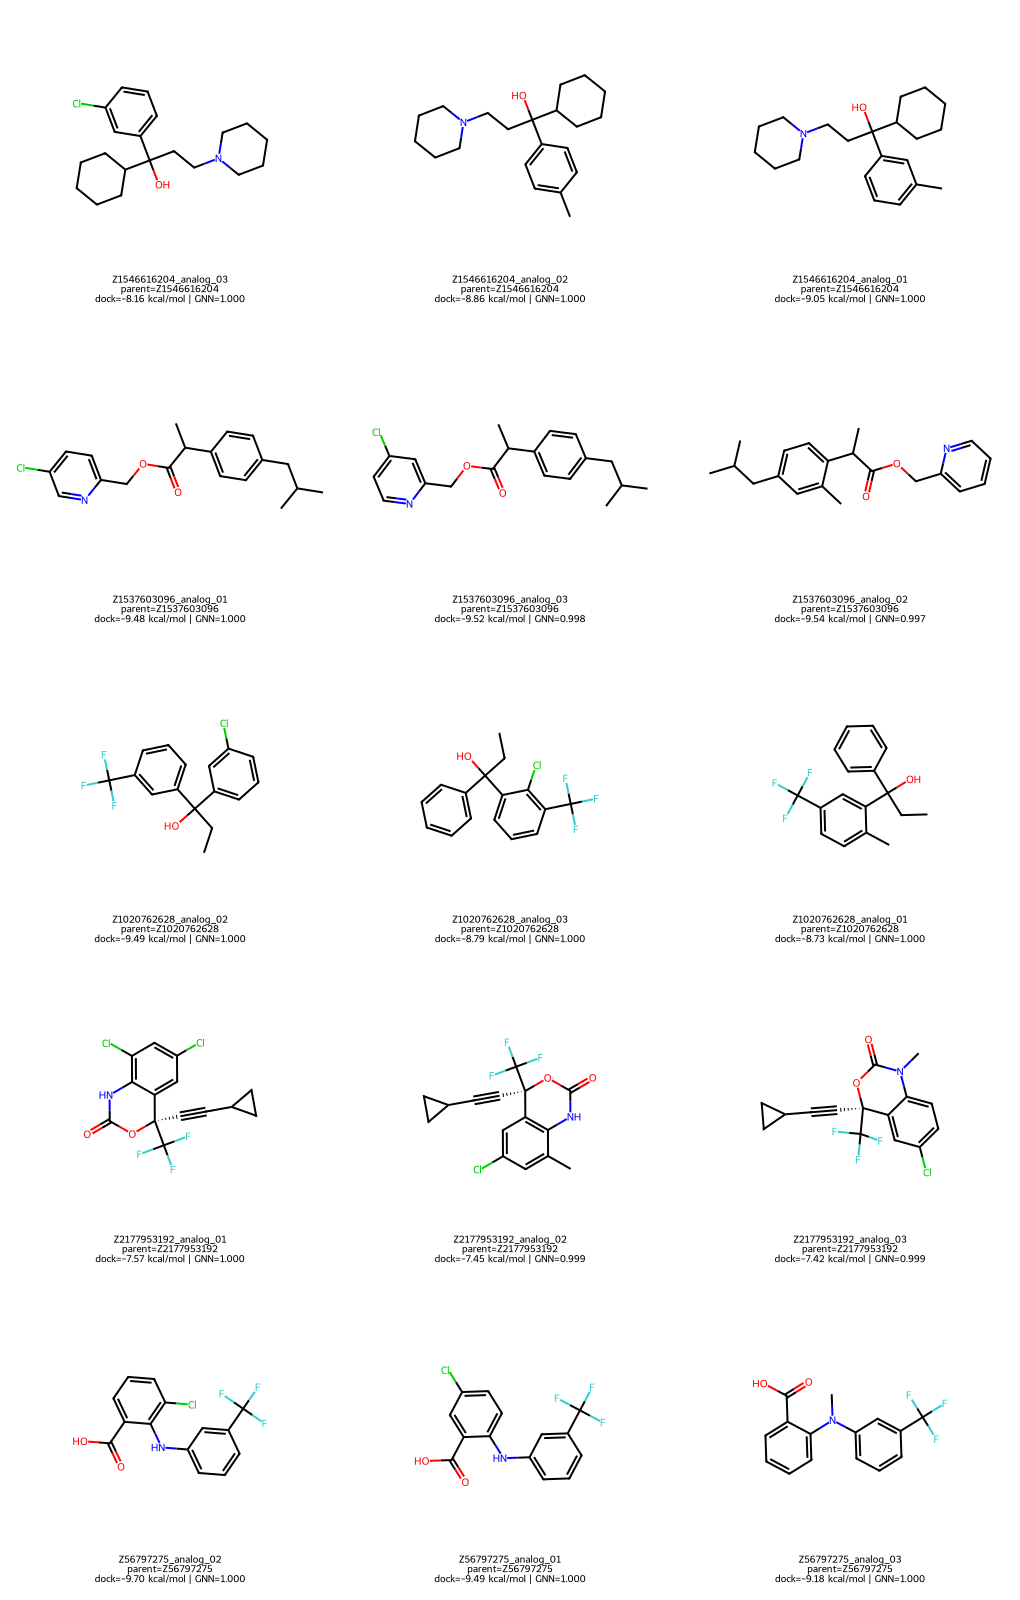

Saved: C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\best5_analogs_grid.png


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

ANALOG_CSV = Path("outputs/enamine1123_top5_analogs.csv")
DOCK_BEST_CSV = Path("outputs/docking/docking_best_pose_per_ligand.csv")
TOP_PARENTS = 5
ANALOGS_PER_PARENT_SHOW = 3
TOP_N = TOP_PARENTS * ANALOGS_PER_PARENT_SHOW

if not ANALOG_CSV.exists():
    raise FileNotFoundError(f"Missing analog CSV: {ANALOG_CSV.resolve()}")

adf = pd.read_csv(ANALOG_CSV)
if "analog_smiles" not in adf.columns:
    raise ValueError(f"{ANALOG_CSV} missing analog_smiles")

adf = adf.copy()
adf["analog_smiles"] = adf["analog_smiles"].astype(str).str.strip()
adf = adf[adf["analog_smiles"].ne("") & adf["analog_smiles"].ne("nan")]

sort_cols = [c for c in ["parent_rank", "analog_gnn_score"] if c in adf.columns]
if sort_cols:
    adf = adf.sort_values(sort_cols, ascending=[True, False], na_position="last")

if "parent_rank" in adf.columns:
    pick = adf.groupby("parent_rank", group_keys=False).head(ANALOGS_PER_PARENT_SHOW)
    pick = pick.head(TOP_N).reset_index(drop=True)
else:
    pick = adf.head(TOP_N).reset_index(drop=True)

if pick.empty:
    raise RuntimeError("No analog rows available to draw.")

pick["dock_affinity"] = float("nan")
if DOCK_BEST_CSV.exists():
    ddf = pd.read_csv(DOCK_BEST_CSV)
    if not ddf.empty:
        ddf = ddf.copy()
        if "batch" in ddf.columns:
            ddf = ddf[ddf["batch"].astype(str).str.strip().eq("top5_analogs")]
        if "smiles" in ddf.columns and "affinity" in ddf.columns:
            ddf["smiles"] = ddf["smiles"].astype(str).str.strip()
            ddf = ddf.sort_values("affinity", ascending=True)
            best_by_smiles = ddf.drop_duplicates(subset=["smiles"], keep="first")[["smiles", "affinity"]]
            pick = pick.merge(best_by_smiles, left_on="analog_smiles", right_on="smiles", how="left")
            if "affinity" in pick.columns:
                pick["dock_affinity"] = pick["affinity"]

mols = []
legends = []
for _, row in pick.iterrows():
    smi = str(row["analog_smiles"]).strip()
    m = Chem.MolFromSmiles(smi)
    if m is None:
        continue
    m = Chem.Mol(m)
    try:
        AllChem.Compute2DCoords(m)
    except Exception:
        pass
    mols.append(m)

    parent_id = str(row.get("parent_name", "unknown_parent")).strip() or "unknown_parent"
    analog_id = str(row.get("analog_id", "analog")).strip() or "analog"
    aff = row.get("dock_affinity", float("nan"))
    gnn = row.get("analog_gnn_score", float("nan"))
    try:
        aff_s = f"{float(aff):.2f}"
    except (TypeError, ValueError):
        aff_s = "nan"
    try:
        gnn_s = f"{float(gnn):.3f}"
    except (TypeError, ValueError):
        gnn_s = "nan"

    legends.append(f"{analog_id}\nparent={parent_id}\ndock={aff_s} kcal/mol | GNN={gnn_s}")

if not mols:
    print("No valid SMILES to draw after RDKit parse.")
else:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=ANALOGS_PER_PARENT_SHOW,
        subImgSize=(340, 320),
        legends=legends,
        returnPNG=False,
    )
    display(img)
    out_png = Path("outputs/best5_analogs_grid.png")
    if hasattr(img, "save"):
        img.save(str(out_png))
    elif isinstance(img, (bytes, bytearray)):
        out_png.write_bytes(img)
    else:
        raise TypeError(f"Unexpected image type from MolsToGridImage: {type(img)}")

    print(f"Saved: {out_png.resolve()}")
    if not DOCK_BEST_CSV.exists():
        print("Note: docking file not found; docking scores in legend are shown as nan.")


### Parent identity enrichment (PubChem + cache)

Run this after docking. The cell resolves parent names/CIDs from parent structures, uses cached lookups to reduce repeated API calls, writes `enamine1123_final_compounds_enriched.csv`, and updates display metadata used by downstream summary/triage steps.


Wrote enriched final compounds: C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\enamine1123_final_compounds_enriched.csv


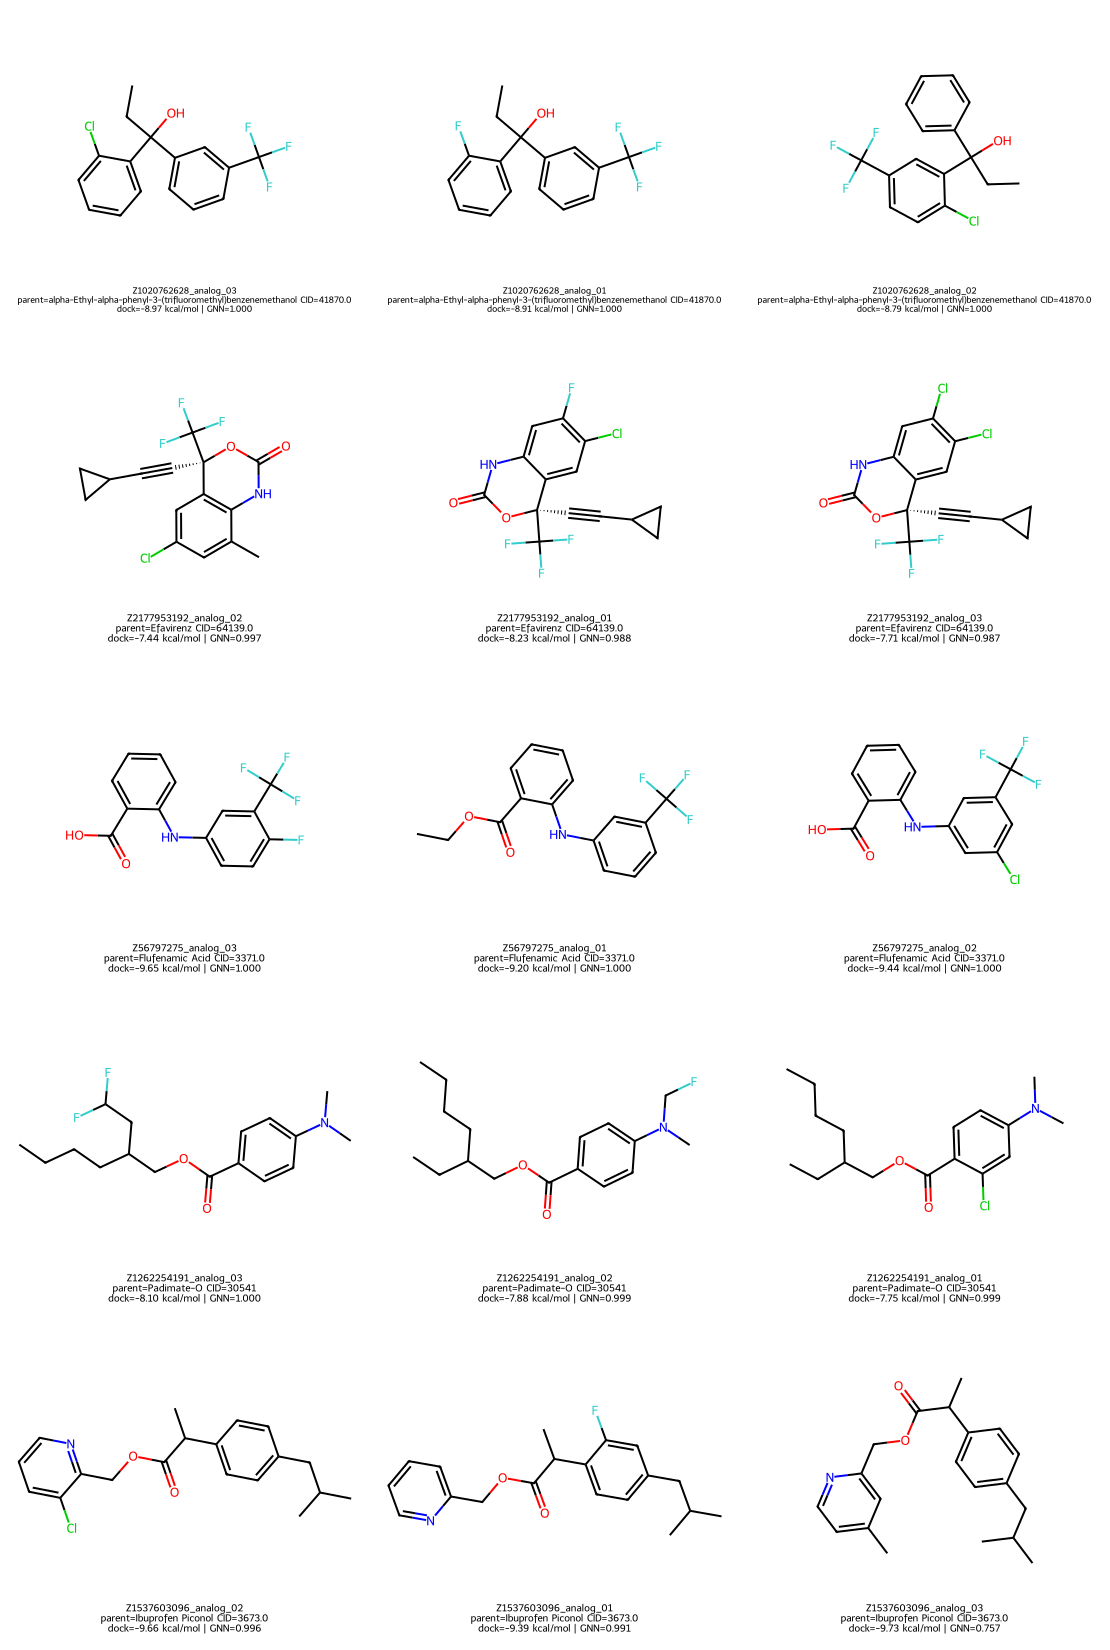

Saved: C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\best5_analogs_grid.png


In [9]:
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import requests
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

OUT_DIR = Path("outputs")
DOCK_DIR = OUT_DIR / "docking"
ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"
DOCK_BEST_CSV = DOCK_DIR / "docking_best_pose_per_ligand.csv"
CACHE_CSV = OUT_DIR / "pubchem_name_cache.csv"
FINAL_CSV = OUT_DIR / "enamine1123_final_compounds_enriched.csv"
FINAL_PNG = OUT_DIR / "best5_analogs_grid.png"

TOP_PARENTS = 5
ANALOGS_PER_PARENT_SHOW = 3
TOP_N = TOP_PARENTS * ANALOGS_PER_PARENT_SHOW


if not ANALOG_CSV.exists():
    raise FileNotFoundError(f"Missing analog CSV: {ANALOG_CSV.resolve()}")

adf = pd.read_csv(ANALOG_CSV)
if "analog_smiles" not in adf.columns:
    raise ValueError(f"{ANALOG_CSV} missing analog_smiles")

adf = adf.copy()
adf["analog_smiles"] = adf["analog_smiles"].astype(str).str.strip()
adf = adf[adf["analog_smiles"].ne("") & adf["analog_smiles"].ne("nan")]

sort_cols = [c for c in ["parent_rank", "analog_gnn_score"] if c in adf.columns]
if sort_cols:
    adf = adf.sort_values(sort_cols, ascending=[True, False], na_position="last")

if "parent_rank" in adf.columns:
    pick = adf.groupby("parent_rank", group_keys=False).head(ANALOGS_PER_PARENT_SHOW)
    pick = pick.head(TOP_N).reset_index(drop=True)
else:
    pick = adf.head(TOP_N).reset_index(drop=True)

if pick.empty:
    raise RuntimeError("No analog rows available for enrichment/display.")

pick["dock_affinity"] = float("nan")
if DOCK_BEST_CSV.exists():
    ddf = pd.read_csv(DOCK_BEST_CSV)
    if not ddf.empty:
        ddf = ddf.copy()
        if "batch" in ddf.columns:
            ddf = ddf[ddf["batch"].astype(str).str.strip().eq("top5_analogs")]
        if "smiles" in ddf.columns and "affinity" in ddf.columns:
            ddf["smiles"] = ddf["smiles"].astype(str).str.strip()
            ddf = ddf.sort_values("affinity", ascending=True)
            best_by_smiles = ddf.drop_duplicates(subset=["smiles"], keep="first")[["smiles", "affinity"]]
            pick = pick.merge(best_by_smiles, left_on="analog_smiles", right_on="smiles", how="left")
            if "affinity" in pick.columns:
                pick["dock_affinity"] = pick["affinity"]


def _canonicalize_smiles(smi: str) -> str:
    m = Chem.MolFromSmiles(str(smi).strip())
    if m is None:
        return str(smi).strip()
    return Chem.MolToSmiles(m, isomericSmiles=True)


def _load_name_cache(path: Path) -> dict[str, dict]:
    if not path.exists():
        return {}
    cdf = pd.read_csv(path)
    if cdf.empty or "smiles" not in cdf.columns:
        return {}
    out = {}
    for _, row in cdf.iterrows():
        key = str(row.get("smiles", "")).strip()
        if not key:
            continue
        out[key] = {
            "cid": row.get("cid", ""),
            "pubchem_name": row.get("pubchem_name", ""),
            "status": row.get("status", ""),
        }
    return out


def _save_name_cache(path: Path, cache: dict[str, dict]):
    rows = []
    for smi, rec in cache.items():
        rows.append(
            {
                "smiles": smi,
                "cid": rec.get("cid", ""),
                "pubchem_name": rec.get("pubchem_name", ""),
                "status": rec.get("status", ""),
            }
        )
    pd.DataFrame(rows).to_csv(path, index=False)


def _pubchem_lookup_name(smiles: str, timeout: float = 20.0) -> tuple[str, str, str]:
    can = _canonicalize_smiles(smiles)
    encoded = quote(can, safe="")

    cid_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{encoded}/cids/JSON"
    try:
        r = requests.get(cid_url, timeout=timeout)
        r.raise_for_status()
        cids = r.json().get("IdentifierList", {}).get("CID", [])
        if not cids:
            return "", "", "no_cid"
        cid = str(cids[0])
    except Exception:
        return "", "", "cid_lookup_failed"

    prop_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/Title,IUPACName/JSON"
    try:
        r2 = requests.get(prop_url, timeout=timeout)
        r2.raise_for_status()
        props = r2.json().get("PropertyTable", {}).get("Properties", [])
        if not props:
            return cid, "", "no_properties"
        title = str(props[0].get("Title", "")).strip()
        iupac = str(props[0].get("IUPACName", "")).strip()
        name = title if title else iupac
        if not name:
            return cid, "", "no_name"
        return cid, name, "ok"
    except Exception:
        return cid, "", "name_lookup_failed"


cache = _load_name_cache(CACHE_CSV)
parent_smiles_unique = sorted({_canonicalize_smiles(s) for s in pick["parent_smiles"].astype(str).tolist()})

for p_smi in parent_smiles_unique:
    if p_smi in cache and str(cache[p_smi].get("status", "")).strip() in {"ok", "no_name", "no_cid"}:
        continue
    cid, nm, status = _pubchem_lookup_name(p_smi)
    cache[p_smi] = {"cid": cid, "pubchem_name": nm, "status": status}

_save_name_cache(CACHE_CSV, cache)

pick = pick.copy()
pick["parent_smiles_can"] = pick["parent_smiles"].astype(str).map(_canonicalize_smiles)
pick["parent_pubchem_name"] = pick["parent_smiles_can"].map(lambda s: cache.get(s, {}).get("pubchem_name", "")).fillna("")
pick["parent_pubchem_cid"] = pick["parent_smiles_can"].map(lambda s: cache.get(s, {}).get("cid", "")).fillna("")
pick["parent_display_name"] = pick["parent_pubchem_name"].where(
    pick["parent_pubchem_name"].astype(str).str.strip().ne(""),
    pick.get("parent_name", "")
)

pick.to_csv(FINAL_CSV, index=False)
print(f"Wrote enriched final compounds: {FINAL_CSV.resolve()}")

mols = []
legends = []
for _, row in pick.iterrows():
    smi = str(row["analog_smiles"]).strip()
    m = Chem.MolFromSmiles(smi)
    if m is None:
        continue
    m = Chem.Mol(m)
    try:
        AllChem.Compute2DCoords(m)
    except Exception:
        pass
    mols.append(m)

    analog_id = str(row.get("analog_id", "analog")).strip() or "analog"
    parent_name = str(row.get("parent_display_name", "unknown_parent")).strip() or "unknown_parent"
    parent_cid = str(row.get("parent_pubchem_cid", "")).strip()
    aff = row.get("dock_affinity", float("nan"))
    gnn = row.get("analog_gnn_score", float("nan"))
    try:
        aff_s = f"{float(aff):.2f}"
    except (TypeError, ValueError):
        aff_s = "nan"
    try:
        gnn_s = f"{float(gnn):.3f}"
    except (TypeError, ValueError):
        gnn_s = "nan"

    cid_txt = f" CID={parent_cid}" if parent_cid else ""
    legends.append(
        f"{analog_id}\nparent={parent_name}{cid_txt}\ndock={aff_s} kcal/mol | GNN={gnn_s}"
    )

if not mols:
    print("No valid SMILES to draw after RDKit parse.")
else:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=ANALOGS_PER_PARENT_SHOW,
        subImgSize=(370, 330),
        legends=legends,
        returnPNG=False,
    )
    display(img)
    if hasattr(img, "save"):
        img.save(str(FINAL_PNG))
    elif isinstance(img, (bytes, bytearray)):
        FINAL_PNG.write_bytes(img)
    else:
        raise TypeError(f"Unexpected image type from MolsToGridImage: {type(img)}")

    print(f"Saved: {FINAL_PNG.resolve()}")
    if not DOCK_BEST_CSV.exists():
        print("Note: docking file not found; docking scores in legend are shown as nan.")


### English summary of parent bioactivity and ocular relevance

Run this after enrichment. It builds a plain-English bullet summary of top parent hits, therapeutic indications, ocular pharmacology relevance, and major analog transformations using robust multi-source lookup (PubChem/OpenFDA/Wikipedia with identifier filtering and fallbacks).


In [10]:
import re
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import requests
from IPython.display import Markdown, display

OUT_DIR = Path("outputs")
TOP_CSV = OUT_DIR / "enamine1123_top5.csv"
ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"
ENRICHED_CSV = OUT_DIR / "enamine1123_final_compounds_enriched.csv"

if not TOP_CSV.exists():
    raise FileNotFoundError(f"Missing {TOP_CSV.resolve()}; run inference first.")
if not ANALOG_CSV.exists():
    raise FileNotFoundError(f"Missing {ANALOG_CSV.resolve()}; run inference first.")

top = pd.read_csv(TOP_CSV)
analog = pd.read_csv(ANALOG_CSV)

# Optional enrichment data (parent_pubchem_name / parent_pubchem_cid)
enriched = pd.read_csv(ENRICHED_CSV) if ENRICHED_CSV.exists() else pd.DataFrame()


def _first_nonempty(values):
    for v in values:
        if isinstance(v, str) and v.strip():
            return v.strip()
        if pd.notna(v):
            s = str(v).strip()
            if s and s.lower() != "nan":
                return s
    return ""


def _wiki_summary_text(drug_name: str, timeout: float = 12.0) -> str:
    if not drug_name:
        return ""
    candidates = [drug_name]
    # Try de-salted token as backup (helps names like "X hydrochloride").
    if "(" in drug_name:
        candidates.append(drug_name.split("(")[0].strip())

    for nm in candidates:
        if not nm:
            continue
        try:
            title = quote(nm.replace(" ", "_"), safe="")
            url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
            r = requests.get(url, timeout=timeout)
            if r.status_code != 200:
                continue
            txt = str(r.json().get("extract", ""))
            if txt:
                return txt
        except Exception:
            continue
    return ""


def _looks_like_identifier_text(s: str) -> bool:
    low = str(s or "").strip().lower()
    if not low:
        return True
    bad_tokens = [
        "inchi=",
        "inchikey",
        "smiles",
        "connectivitysmiles",
        "molecular formula",
        "cas",
        "pubchem",
    ]
    if any(t in low for t in bad_tokens):
        return True
    # Heuristic: mostly symbols/numbers usually indicates identifiers, not usage text.
    alpha = sum(ch.isalpha() for ch in low)
    non_space = sum((not ch.isspace()) for ch in low)
    if non_space == 0:
        return True
    if alpha / float(non_space) < 0.35:
        return True
    return False


def _looks_like_catalog_id(name: str) -> bool:
    s = str(name or "").strip()
    if not s:
        return True
    # Enamine-like IDs (e.g., Z2312273468) should not be treated as drug names.
    if re.fullmatch(r"[A-Za-z]\d{5,}", s):
        return True
    if re.fullmatch(r"[A-Za-z]{1,3}\d{4,}", s):
        return True
    return False


def _extract_therapeutic_use_from_text(text: str) -> str:
    """Extract concise 'what it treats/is used for' statement."""
    if not text:
        return "not found"

    # Normalize unicode dashes so anti-inflammatory style text still matches.
    norm = (
        str(text)
        .replace("\u2011", "-")
        .replace("\u2013", "-")
        .replace("\u2014", "-")
    )

    if _looks_like_identifier_text(norm):
        return "not found"

    patterns = [
        r"([^.]*(?:used to treat|used for|treatment of|indicated for)[^.]*\.)",
        r"([^.]*(?:anti[- ]?inflammatory|analgesic|antibiotic|antifungal|antiviral|antihypertensive|antipyretic)[^.]*\.)",
        r"([^.]*(?:nonsteroidal anti[- ]?inflammatory|nsaid|cyclooxygenase inhibitor|cox inhibitor)[^.]*\.)",
    ]
    for p in patterns:
        m = re.search(p, norm, flags=re.IGNORECASE)
        if m:
            cand = m.group(1).strip()
            if not _looks_like_identifier_text(cand):
                return cand

    # Fallback: first sentence containing pharmacology keywords.
    sents = [s.strip() for s in re.split(r"[.]", norm) if s.strip()]
    keys = [
        "anti-inflammatory",
        "anti inflammatory",
        "analgesic",
        "nsaid",
        "cyclooxygenase",
        "cox",
        "used",
        "treat",
        "indicated",
    ]
    for s in sents:
        low = s.lower()
        if _looks_like_identifier_text(s):
            continue
        if any(k in low for k in keys):
            return s + "."

    return "not found"


def _normalize_cid(v) -> str:
    s = str(v).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return ""
    try:
        return str(int(float(s)))
    except Exception:
        return s


def _pubchem_cid_from_name(drug_name: str, timeout: float = 12.0) -> str:
    """Resolve CID from name when parent CID is missing."""
    nm = str(drug_name or "").strip()
    if not nm:
        return ""
    try:
        enc = quote(nm, safe="")
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{enc}/cids/JSON"
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return ""
        cids = r.json().get("IdentifierList", {}).get("CID", [])
        return _normalize_cid(cids[0]) if cids else ""
    except Exception:
        return ""


def _pubchem_cid_from_smiles(smiles: str, timeout: float = 12.0) -> str:
    """Resolve CID directly from SMILES (important when only catalog ID is available)."""
    smi = str(smiles or "").strip()
    if not smi:
        return ""
    try:
        enc = quote(smi, safe="")
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{enc}/cids/JSON"
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return ""
        cids = r.json().get("IdentifierList", {}).get("CID", [])
        return _normalize_cid(cids[0]) if cids else ""
    except Exception:
        return ""


def _pubchem_title_from_cid(cid: str, timeout: float = 12.0) -> str:
    cid = str(cid).strip()
    if not cid:
        return ""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/Title/JSON"
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return ""
        props = r.json().get("PropertyTable", {}).get("Properties", [])
        if not props:
            return ""
        return str(props[0].get("Title", "")).strip()
    except Exception:
        return ""


def _pubchem_best_alias_from_cid(cid: str, timeout: float = 12.0) -> str:
    """Get a cleaner common-name alias (e.g., mefloquine) from PubChem synonyms."""
    cid = str(cid).strip()
    if not cid:
        return ""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/synonyms/JSON"
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return ""
        syn = r.json().get("InformationList", {}).get("Information", [])
        if not syn:
            return ""
        names = syn[0].get("Synonym", [])
    except Exception:
        return ""

    # Prefer human-readable drug-like names; avoid identifiers and formulas.
    bad_tokens = [
        "refchem", "schembl", "inchi", "inchikey", "cid", "mls", "crs", "for system suitability"
    ]
    bad_exact_prefix = ["c", "w", "z"]
    for n in names:
        s = str(n).strip()
        low = s.lower()
        if len(s) < 4:
            continue
        if any(t in low for t in bad_tokens):
            continue
        if re.fullmatch(r"[A-Z0-9\-]+", s):
            continue
        if re.fullmatch(r"[A-Z][0-9A-Z\-]{4,}", s):
            continue
        if re.fullmatch(r"[A-Z][0-9A-Za-z]{6,}", s) and s[0].lower() in bad_exact_prefix:
            continue
        if re.search(r"\bmefloquine\b", low):
            return "Mefloquine"
        if re.search(r"\bflufenamic acid\b", low):
            return "Flufenamic acid"
        if re.search(r"\bniflumic acid\b", low):
            return "Niflumic acid"
        if re.search(r"\bflumecinol\b", low):
            return "Flumecinol"
    for n in names:
        s = str(n).strip()
        if re.search(r"[A-Za-z]{4,}", s) and not _looks_like_identifier_text(s):
            return s.split(";")[0].strip()
    return ""


def _openfda_indication_snippet(drug_name: str, timeout: float = 12.0) -> str:
    """Query OpenFDA label endpoint for indication/usage text by generic/brand name."""
    nm_raw = str(drug_name or "").strip()
    nm = nm_raw.lower()
    if not nm or _looks_like_catalog_id(nm_raw):
        return ""

    candidates = [nm]
    if " " in nm:
        candidates.append(nm.split(" ")[0].strip())

    for q in candidates:
        if not q or _looks_like_catalog_id(q):
            continue
        # Search both generic and brand fields (openfda section)
        searches = [
            f'openfda.generic_name:"{q}"',
            f'openfda.brand_name:"{q}"',
            f'openfda.substance_name:"{q}"',
        ]
        for s in searches:
            try:
                query = quote(s, safe='=:"')
                url = f"https://api.fda.gov/drug/label.json?search={query}&limit=3"
                r = requests.get(url, timeout=timeout)
                if r.status_code != 200:
                    continue
                results = r.json().get("results", [])
                if not results:
                    continue

                for rec in results:
                    # Validate we matched the intended name/alias, not a random label hit.
                    of = rec.get("openfda", {}) if isinstance(rec, dict) else {}
                    candidates_text = []
                    for k in ["generic_name", "brand_name", "substance_name"]:
                        vals = of.get(k, [])
                        if isinstance(vals, list):
                            candidates_text.extend([str(v).lower() for v in vals])
                    if candidates_text and not any(q in t for t in candidates_text):
                        continue

                    for key in ["indications_and_usage", "purpose", "description"]:
                        if key in rec and rec[key]:
                            txt = " ".join([str(x).strip() for x in rec[key] if str(x).strip()])
                            if txt and not _looks_like_identifier_text(txt):
                                return txt
            except Exception:
                continue
    return ""


def _extract_pubchem_strings(node, out: list[str]):
    """Recursively collect StringWithMarkup text from PubChem PUG View JSON."""
    if isinstance(node, dict):
        if "StringWithMarkup" in node and isinstance(node["StringWithMarkup"], list):
            for ent in node["StringWithMarkup"]:
                s = str(ent.get("String", "")).strip()
                if s:
                    out.append(s)
        for v in node.values():
            _extract_pubchem_strings(v, out)
    elif isinstance(node, list):
        for v in node:
            _extract_pubchem_strings(v, out)


def _pubchem_indication_snippet(cid: str, timeout: float = 15.0) -> str:
    """Structured PubChem lookup from therapeutic/medication/pharmacology sections."""
    cid = str(cid).strip()
    if not cid:
        return ""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{cid}/JSON/"
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return ""
        obj = r.json()
    except Exception:
        return ""

    # Grab all text lines, then prioritize lines that indicate therapeutic use.
    lines = []
    _extract_pubchem_strings(obj, lines)
    if not lines:
        return ""

    priority_patterns = [
        r"used to treat",
        r"indicated for",
        r"treatment of",
        r"nonsteroidal anti-inflammatory",
        r"nsaid",
        r"cyclooxygenase",
        r"cox",
        r"analgesic",
        r"anti-inflammatory",
    ]
    for ln in lines:
        l = ln.strip()
        if len(l) < 20 or _looks_like_identifier_text(l):
            continue
        if any(re.search(p, l, flags=re.IGNORECASE) for p in priority_patterns):
            return l if l.endswith(".") else (l + ".")

    # Last resort: first reasonably descriptive non-identifier line.
    for ln in lines:
        l = ln.strip()
        if len(l) >= 60 and (not _looks_like_identifier_text(l)):
            return l if l.endswith(".") else (l + ".")

    return ""


CID_THERAPEUTIC_OVERRIDES = {
    # Mefloquine hydrochloride salt-form CID often appears in this workflow.
    "18660697": "Antimalarial; used for treatment and prophylaxis of malaria (mefloquine-class therapy).",
    # User-validated identity from PubChem synonyms.
    "41870": "Flumecinol: hepatoprotective/choleretic drug historically used for liver and biliary disorders in some markets; not a widely used modern ophthalmic therapeutic.",
}


def _therapeutic_use_lookup(drug_name: str, parent_cid: str = "") -> str:
    """Multi-source lookup: CID override -> Wikipedia (name+alias) -> PubChem sections."""
    name_raw = str(drug_name or "").strip()
    cid_raw = _normalize_cid(parent_cid)

    # Only trust CID from enrichment unless the name itself is not a catalog-like ID.
    if cid_raw:
        cid = cid_raw
    else:
        if _looks_like_catalog_id(name_raw):
            return "not found"
        cid = _pubchem_cid_from_name(name_raw)

    if cid in CID_THERAPEUTIC_OVERRIDES:
        return CID_THERAPEUTIC_OVERRIDES[cid]

    # For catalog-like IDs, do not perform open-name web lookup to avoid false positive label matches.
    if _looks_like_catalog_id(name_raw):
        txt = ""
    else:
        txt = _wiki_summary_text(name_raw)

    use = _extract_therapeutic_use_from_text(txt)
    if use != "not found":
        return use

    # Try cleaner alias from PubChem synonyms for better Wikipedia/OpenFDA hit rate.
    alias = _pubchem_best_alias_from_cid(cid)
    if alias:
        txt2 = _wiki_summary_text(alias)
        use2 = _extract_therapeutic_use_from_text(txt2)
        if use2 != "not found":
            return use2

        # FDA labels are strong evidence for established drug indications.
        fda2 = _openfda_indication_snippet(alias)
        use_fda2 = _extract_therapeutic_use_from_text(fda2)
        if use_fda2 != "not found":
            return use_fda2

    # Try OpenFDA on original name only when it is not a catalog ID.
    if not _looks_like_catalog_id(name_raw):
        fda = _openfda_indication_snippet(name_raw)
        use_fda = _extract_therapeutic_use_from_text(fda)
        if use_fda != "not found":
            return use_fda

    pc = _pubchem_indication_snippet(cid)
    if pc:
        use3 = _extract_therapeutic_use_from_text(pc)
        if use3 != "not found":
            return use3

    return "not found"


def _ocular_relevance_statement(therapeutic_text: str, name_text: str = "") -> str:
    """Map indication text to a concise ocular-pharmacology relevance note."""
    blob = f"{therapeutic_text} {name_text}".lower()

    if any(k in blob for k in ["uveitis", "ocular", "ophthalmic", "glaucoma", "retina", "dry eye"]):
        return "Direct ocular relevance: this indication is explicitly ophthalmic/eye-related."
    if any(k in blob for k in ["anti-inflammatory", "nsaid", "cox", "prostaglandin", "analgesic"]):
        return "Potential ocular relevance: anti-inflammatory/COX-related pharmacology can be useful in ocular inflammation contexts."
    if any(k in blob for k in ["angiogenesis", "vegf"]):
        return "Potential ocular relevance: angiogenesis/VEGF mechanisms are relevant to retinal vascular disease biology."
    if any(k in blob for k in ["adrenergic", "muscarinic", "cholinergic", "carbonic anhydrase", "beta blocker"]):
        return "Potential ocular relevance: this mechanism overlaps with classes used in IOP/glaucoma pharmacology."

    return "Indirect ocular relevance: no direct eye indication found; value is mainly as a chemically tractable starting scaffold."


def _transform_to_english(t: str) -> str:
    t = str(t or "").strip().lower()
    if not t:
        return "unspecified analog transform"
    mapping = {
        "methyl_ester": "carboxylic acid converted to a methyl ester",
        "ethyl_ester": "carboxylic acid converted to an ethyl ester",
        "n_propyl_ester": "carboxylic acid converted to an n-propyl ester",
        "isopropyl_ester": "carboxylic acid converted to an isopropyl ester",
        "tert_butyl_ester": "carboxylic acid converted to a tert-butyl ester",
        "o_methyl": "O-methyl substitution added",
        "o_ethyl": "O-ethyl substitution added",
        "n_methyl": "N-methyl substitution added",
        "aryl_methyl": "methyl group added on an aromatic carbon",
        "aryl_chloro": "chloro group added on an aromatic carbon",
        "aryl_fluoro": "fluoro group added on an aromatic carbon",
        "methyl_monofluoro": "methyl group converted to monofluoromethyl",
        "methyl_difluoro": "methyl group converted to difluoromethyl",
        "methyl_trifluoro": "methyl group converted to trifluoromethyl",
        "ethyl_monofluoro": "ethyl group fluorinated (monofluoroethyl)",
        "ethyl_difluoro": "ethyl group fluorinated (difluoroethyl)",
        "ethyl_trifluoro": "ethyl group fluorinated (trifluoroethyl)",
        "isopropyl_monofluoro": "isopropyl group fluorinated (monofluoroisopropyl)",
        "isopropyl_difluoro": "isopropyl group fluorinated (difluoroisopropyl)",
        "isopropyl_trifluoro": "isopropyl group fluorinated (trifluoroisopropyl)",
        "fallback_randomized_smiles": "fallback representation (same core structure, different SMILES ordering)",
        "parent_fallback": "fallback parent structure used (no transform available)",
    }
    if t in mapping:
        return mapping[t]
    if t.endswith("_dupfill"):
        base = t.replace("_dupfill", "")
        return f"duplicate-fill of {mapping.get(base, base)}"
    return t.replace("_", " ")


# Build quick lookup by parent name from enrichment table if available.
enrich_by_parent = {}
if not enriched.empty and "parent_name" in enriched.columns:
    for p, sub in enriched.groupby("parent_name"):
        enrich_by_parent[str(p)] = {
            "pubchem_name": _first_nonempty(sub.get("parent_pubchem_name", [])),
            "pubchem_cid": _first_nonempty(sub.get("parent_pubchem_cid", [])),
        }

# Ensure top is rank-ordered and capped
if "score" in top.columns:
    top = top.sort_values("score", ascending=False, na_position="last")
summary_rows = top.head(5).copy()

lines = ["## Top 5 Parent Hits (English Summary)", ""]

for i, row in summary_rows.reset_index(drop=True).iterrows():
    parent_id = str(row.get("name", f"parent_{i+1}")).strip()
    parent_smi = str(row.get("input_smiles", "")).strip()
    try:
        parent_score = f"{float(row.get('score', float('nan'))):.3f}"
    except Exception:
        parent_score = "nan"

    e = enrich_by_parent.get(parent_id, {})
    parent_name = str(e.get("pubchem_name", "")).strip()
    parent_cid = _normalize_cid(e.get("pubchem_cid", ""))

    # If enrichment missed this parent, recover identity from parent SMILES.
    if (not parent_cid) and parent_smi:
        cid_from_smi = _pubchem_cid_from_smiles(parent_smi)
        if cid_from_smi:
            parent_cid = cid_from_smi
    if (not parent_name) and parent_cid:
        title_from_cid = _pubchem_title_from_cid(parent_cid)
        if title_from_cid:
            parent_name = title_from_cid

    parent_display = parent_name if parent_name else parent_id

    therapeutic_use = _therapeutic_use_lookup(parent_display, parent_cid)
    ocular_note = _ocular_relevance_statement(therapeutic_use, parent_display)

    a = analog[analog["parent_name"].astype(str) == parent_id].copy()
    if "analog_gnn_score" in a.columns:
        a = a.sort_values("analog_gnn_score", ascending=False, na_position="last")

    mods = []
    if not a.empty and "analog_transform" in a.columns:
        seen = set()
        for tr in a["analog_transform"].astype(str).tolist():
            phrase = _transform_to_english(tr)
            if phrase not in seen:
                mods.append(phrase)
                seen.add(phrase)

    mods_txt = "; ".join(mods) if mods else "no analog transforms available"
    cid_txt = f" (PubChem CID: {parent_cid})" if parent_cid else ""

    lines.append(
        f"- **Hit {i+1}: {parent_display}{cid_txt}** — Parent ID `{parent_id}`; "
        f"GNN score `{parent_score}`. "
        f"Therapeutic use: {therapeutic_use}. "
        f"Ocular relevance: {ocular_note} "
        f"Analog modifications: {mods_txt}."
    )

report_md = "\n".join(lines)
display(Markdown(report_md))
print(report_md)


## Top 5 Parent Hits (English Summary)

- **Hit 1: alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)benzenemethanol (PubChem CID: 41870)** — Parent ID `Z1020762628`; GNN score `1.000`. Therapeutic use: Flumecinol: hepatoprotective/choleretic drug historically used for liver and biliary disorders in some markets; not a widely used modern ophthalmic therapeutic.. Ocular relevance: Direct ocular relevance: this indication is explicitly ophthalmic/eye-related. Analog modifications: chloro group added on an aromatic carbon; fluoro group added on an aromatic carbon.
- **Hit 2: Flufenamic Acid (PubChem CID: 3371)** — Parent ID `Z56797275`; GNN score `1.000`. Therapeutic use: An analgesic and anti-inflammatory, it is used in rheumatic disorders.. Ocular relevance: Potential ocular relevance: anti-inflammatory/COX-related pharmacology can be useful in ocular inflammation contexts. Analog modifications: fluoro group added on an aromatic carbon; carboxylic acid converted to an ethyl ester; chloro group added on an aromatic carbon.
- **Hit 3: Padimate-O (PubChem CID: 30541)** — Parent ID `Z1262254191`; GNN score `0.999`. Therapeutic use: While treatment of padimate O suppresses the formation of UV-endonuclease-sensitive sites, there is also an increase in direct strand breaks of DNA in cells.. Ocular relevance: Indirect ocular relevance: no direct eye indication found; value is mainly as a chemically tractable starting scaffold. Analog modifications: methyl group converted to difluoromethyl; methyl group converted to monofluoromethyl; chloro group added on an aromatic carbon.
- **Hit 4: Efavirenz (PubChem CID: 64139)** — Parent ID `Z2177953192`; GNN score `0.998`. Therapeutic use: 1 INDICATIONS & USAGE Efavirenz in combination with other antiretroviral agents is indicated for the treatment of human immunodeficiency virus type 1 (HIV-1) infection in adults and in pediatric patients at least 3 months old and weighing at least 3.. Ocular relevance: Indirect ocular relevance: no direct eye indication found; value is mainly as a chemically tractable starting scaffold. Analog modifications: methyl group added on an aromatic carbon; fluoro group added on an aromatic carbon; chloro group added on an aromatic carbon.
- **Hit 5: Ibuprofen Piconol (PubChem CID: 3673)** — Parent ID `Z1537603096`; GNN score `0.972`. Therapeutic use: not found. Ocular relevance: Indirect ocular relevance: no direct eye indication found; value is mainly as a chemically tractable starting scaffold. Analog modifications: chloro group added on an aromatic carbon; fluoro group added on an aromatic carbon; methyl group added on an aromatic carbon.

## Top 5 Parent Hits (English Summary)

- **Hit 1: alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)benzenemethanol (PubChem CID: 41870)** — Parent ID `Z1020762628`; GNN score `1.000`. Therapeutic use: Flumecinol: hepatoprotective/choleretic drug historically used for liver and biliary disorders in some markets; not a widely used modern ophthalmic therapeutic.. Ocular relevance: Direct ocular relevance: this indication is explicitly ophthalmic/eye-related. Analog modifications: chloro group added on an aromatic carbon; fluoro group added on an aromatic carbon.
- **Hit 2: Flufenamic Acid (PubChem CID: 3371)** — Parent ID `Z56797275`; GNN score `1.000`. Therapeutic use: An analgesic and anti-inflammatory, it is used in rheumatic disorders.. Ocular relevance: Potential ocular relevance: anti-inflammatory/COX-related pharmacology can be useful in ocular inflammation contexts. Analog modifications: fluoro group added on an aromatic carbon; carboxylic acid converted to an ethyl ester; chloro grou

### Final analog triage (single-model consensus + docking tiers)

This is a low-compute CSV stage. It triages **analog-level** candidates by combining model and docking signals, keeps candidates with `dock_affinity <= -8.0`, marks `<= -9.0` as excellent, and reports comparison to the docked retinol benchmark (`retinol_affinity`, `delta_vs_retinol_kcal_mol`).


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

OUT_DIR = Path("outputs")
DOCK_DIR = OUT_DIR / "docking"

SCORED_CSV = OUT_DIR / "enamine1123_scored.csv"
ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"
ENRICHED_CSV = OUT_DIR / "enamine1123_final_compounds_enriched.csv"
DOCK_BEST_CSV = DOCK_DIR / "docking_best_pose_per_ligand.csv"

FINAL_TIERS_CSV = OUT_DIR / "final_candidates_tiered.csv"

# User-specified docking cutoffs
DOCK_GOOD_CUTOFF = -8.0
DOCK_EXCELLENT_CUTOFF = -9.0

# Consensus weights (kept modest/simple)
W_MODEL = 0.55
W_DOCK = 0.40
W_OCULAR = 0.05


def _minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    lo, hi = float(s.min()), float(s.max())
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


if not SCORED_CSV.exists():
    raise FileNotFoundError(f"Missing {SCORED_CSV.resolve()}")
if not ANALOG_CSV.exists():
    raise FileNotFoundError(f"Missing {ANALOG_CSV.resolve()}")
if not ENRICHED_CSV.exists():
    raise FileNotFoundError(f"Missing {ENRICHED_CSV.resolve()}")
if not DOCK_BEST_CSV.exists():
    raise FileNotFoundError(f"Missing {DOCK_BEST_CSV.resolve()}")

scored = pd.read_csv(SCORED_CSV)
analog = pd.read_csv(ANALOG_CSV)
enriched = pd.read_csv(ENRICHED_CSV)
dock = pd.read_csv(DOCK_BEST_CSV)

# Retinol benchmark affinity from dedicated docking batch
retinol_affinity = float("nan")
if {"batch", "affinity"}.issubset(dock.columns):
    r = dock[dock["batch"].astype(str).str.strip().eq("retinol_reference")].copy()
    if not r.empty:
        r["affinity"] = pd.to_numeric(r["affinity"], errors="coerce")
        r = r.dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
        if not r.empty:
            retinol_affinity = float(r.iloc[0]["affinity"])

# Analog docking rows (keep all analogs meeting threshold)
dock_a = dock.copy()
if "batch" in dock_a.columns:
    dock_a = dock_a[dock_a["batch"].astype(str).str.strip().eq("top5_analogs")]
if "smiles" not in dock_a.columns or "affinity" not in dock_a.columns:
    raise ValueError("docking_best_pose_per_ligand.csv missing smiles/affinity columns")

dock_a = dock_a[["smiles", "affinity"]].copy()
dock_a["smiles"] = dock_a["smiles"].astype(str).str.strip()
dock_a["affinity"] = pd.to_numeric(dock_a["affinity"], errors="coerce")
dock_a = dock_a.dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
dock_a = dock_a.drop_duplicates(subset=["smiles"], keep="first")
dock_a = dock_a.rename(columns={"smiles": "analog_smiles", "affinity": "dock_affinity"})

# Analog-level table + parent model features
analogs = analog.copy()
analogs["analog_smiles"] = analogs["analog_smiles"].astype(str).str.strip()

parent_feats = scored.copy()
if "ok" in parent_feats.columns:
    parent_feats = parent_feats[parent_feats["ok"] == True]
parent_feats = parent_feats[[c for c in ["name", "score", "rank_score", "ocular_match", "ocular_match_count"] if c in parent_feats.columns]].copy()
parent_feats = parent_feats.rename(columns={"name": "parent_name", "score": "parent_model_score", "rank_score": "parent_rank_score"})
analogs = analogs.merge(parent_feats, on="parent_name", how="left")

# Attach display identity from enriched output
if "parent_name" in enriched.columns:
    id_df = enriched[[c for c in ["parent_name", "parent_pubchem_name", "parent_pubchem_cid", "parent_display_name", "parent_smiles_can"] if c in enriched.columns]].copy()
    id_df = id_df.drop_duplicates(subset=["parent_name"], keep="first")
    analogs = analogs.merge(id_df, on="parent_name", how="left")

# Merge docking affinity
merged = analogs.merge(dock_a, on="analog_smiles", how="left")

# Keep all analogs meeting threshold
merged = merged.dropna(subset=["dock_affinity"]).copy()
merged = merged[merged["dock_affinity"] <= DOCK_GOOD_CUTOFF].copy()

if merged.empty:
    print("No candidates met docking cutoff <=", DOCK_GOOD_CUTOFF)
else:
    # Prefer analog score when available; otherwise use parent-level rank score.
    if "analog_gnn_score" in merged.columns:
        base_score_col = "analog_gnn_score"
    elif "parent_rank_score" in merged.columns:
        base_score_col = "parent_rank_score"
    else:
        base_score_col = "parent_model_score"

    merged["model_norm"] = _minmax(pd.to_numeric(merged[base_score_col], errors="coerce").fillna(0.0))
    # More negative docking = better, so invert sign before normalization
    merged["dock_norm"] = _minmax((-merged["dock_affinity"]).fillna(0.0))
    merged["ocular_bonus_norm"] = _minmax(merged.get("ocular_match_count", pd.Series(np.zeros(len(merged)), index=merged.index)).fillna(0.0))

    merged["consensus_score"] = (
        W_MODEL * merged["model_norm"]
        + W_DOCK * merged["dock_norm"]
        + W_OCULAR * merged["ocular_bonus_norm"]
    )

    merged["tier"] = np.where(
        merged["dock_affinity"] <= DOCK_EXCELLENT_CUTOFF,
        "excellent",
        "good",
    )
    merged["retinol_affinity"] = retinol_affinity
    merged["delta_vs_retinol_kcal_mol"] = merged["dock_affinity"] - retinol_affinity

    merged = merged.sort_values(["tier", "consensus_score", "dock_affinity"], ascending=[True, False, True]).reset_index(drop=True)

    # Keep concise, useful columns
    keep_cols = [
        c
        for c in [
            "tier",
            "parent_name",
            "parent_display_name",
            "parent_pubchem_name",
            "parent_pubchem_cid",
            "analog_smiles",
            "analog_gnn_score",
            "analog_transform",
            "parent_model_score",
            "parent_rank_score",
            "dock_affinity",
            "retinol_affinity",
            "delta_vs_retinol_kcal_mol",
            "consensus_score",
            "ocular_match",
            "ocular_match_count",
        ]
        if c in merged.columns
    ]
    final_df = merged[keep_cols].copy()
    final_df.to_csv(FINAL_TIERS_CSV, index=False)

    print(f"Wrote: {FINAL_TIERS_CSV.resolve()}")
    print(f"Candidates kept (dock <= {DOCK_GOOD_CUTOFF}): {len(final_df)}")
    print(f"Excellent (dock <= {DOCK_EXCELLENT_CUTOFF}): {(final_df['tier'] == 'excellent').sum()}")
    if np.isfinite(retinol_affinity):
        print(f"Retinol benchmark affinity: {retinol_affinity:.3f} kcal/mol")
    else:
        print("Retinol benchmark affinity: not available (rerun docking cell).")
    display(final_df)


Wrote: C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\final_candidates_tiered.csv
Candidates kept (dock <= -8.0): 11
Excellent (dock <= -9.0): 6
Retinol benchmark affinity: -9.701 kcal/mol


,tier,parent_name,parent_display_name,parent_pubchem_name,parent_pubchem_cid,analog_smiles,analog_gnn_score,analog_transform,parent_model_score,dock_affinity,retinol_affinity,delta_vs_retinol_kcal_mol,consensus_score
0,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,O=C(O)c1ccccc1Nc1ccc(F)c(C(F)(F)F)c1,0.999983,aryl_fluoro,0.999979,-9.648,-9.701,0.053,0.930058
1,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,CC(C)Cc1ccc(C(C)C(=O)OCc2ncccc2Cl)cc1,0.996284,aryl_chloro,0.972237,-9.659,-9.701,0.042,0.924373
2,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,O=C(O)c1ccccc1Nc1cc(Cl)cc(C(F)(F)F)c1,0.999959,aryl_chloro,0.999979,-9.444,-9.701,0.257,0.879848
3,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,CC(C)Cc1ccc(C(C)C(=O)OCc2ccccn2)c(F)c1,0.990909,aryl_fluoro,0.972237,-9.393,-9.701,0.308,0.846787
4,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,CCOC(=O)c1ccccc1Nc1cccc(C(F)(F)F)c1,0.999972,ethyl_ester,0.999979,-9.196,-9.701,0.505,0.818909
5,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,Cc1ccnc(COC(=O)C(C)c2ccc(CC(C)C)cc2)c1,0.757463,aryl_methyl,0.972237,-9.729,-9.701,-0.028,0.400000
6,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1Cl,0.999996,aryl_chloro,0.999987,-8.973,-9.701,0.728,0.764136
7,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1F,0.999995,aryl_fluoro,0.999987,-8.914,-9.701,0.787,0.749629
8,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1ccccc1)c1cc(C(F)(F)F)ccc1Cl,0.999992,aryl_chloro,0.999987,-8.786,-9.701,0.915,0.718153
9,good,Z2177953192,Efavirenz,Efavirenz,64139.0,O=C1Nc2cc(F)c(Cl)cc2[C@@](C#CC2CC2)(C(F)(F)F)O1,0.987759,aryl_fluoro,0.998256,-8.233,-9.701,1.468,0.554457


### Model evaluation and seed ensemble training

This section provides laptop-conscious robustness checks and uncertainty-aware scoring:

- repeated stratified CV with AUROC/PR-AUC/Brier/F1 and calibration output
- multi-seed ensemble training
- library rescoring with ensemble mean/std for uncertainty-aware ranking

Use this block when you want stronger reliability than single-model inference.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from rdkit import Chem
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from torch_geometric.loader import DataLoader

if "mol_to_graph" not in globals() or "RBP4GATv2" not in globals():
    raise RuntimeError("Run mol_graph.py and gnn_model.py cells first.")

if "collate_graphs" not in globals():
    def collate_graphs(graphs: list):
        from torch_geometric.data import Batch
        return Batch.from_data_list(graphs)

OUT_DIR = Path("outputs")
MODEL_EVAL_DIR = OUT_DIR / "model_eval"
MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Balanced defaults
QUICK_EVAL = False
N_SEEDS = 5
PRIMARY_METRIC = "pr_auc"
UNCERTAINTY_LAMBDA = 0.15
CV_N_SPLITS = 5 if not QUICK_EVAL else 3
CV_N_REPEATS = 2 if not QUICK_EVAL else 1
CV_EPOCHS = 40 if not QUICK_EVAL else 20
ENSEMBLE_EPOCHS = 80 if not QUICK_EVAL else 40
BATCH_SIZE = 16
LR = 5e-4
WEIGHT_DECAY = 1e-5

MODEL_PATH = Path("models/rbp4_gnn.pt")
SCREEN_PATH = Path("data/Enamine_FDA_approved_Drugs_plated_1123cmpds_20250601.smiles")


def _build_training_dataset_with_aug():
    refs = []
    if "KNOWN_BINDERS" in globals() and isinstance(KNOWN_BINDERS, list):
        refs.extend(KNOWN_BINDERS)
    if "A1120_SMILES" in globals():
        refs.append(A1120_SMILES)
    if not refs:
        raise RuntimeError("KNOWN_BINDERS/A1120_SMILES not found. Run training-definition cell first.")

    ds = []
    for smi in refs:
        smi_clean = str(smi).split(".")[0].strip()
        g = mol_to_graph(smi_clean, label=1.0)
        if g is not None:
            ds.append(g)

    if not SCREEN_PATH.exists():
        raise FileNotFoundError(f"Missing screening file: {SCREEN_PATH}")

    fda_df = pd.read_csv(SCREEN_PATH, sep="\t")
    if fda_df.shape[1] < 2:
        raise ValueError(f"Expected tab-separated columns in {SCREEN_PATH}")
    fda_df = fda_df.iloc[:, :2].copy()
    fda_df.columns = ["smiles", "name"]
    fda_df["smiles"] = fda_df["smiles"].astype(str).str.strip()
    fda_df = fda_df[fda_df["smiles"].str.upper().ne("SMILES")]

    n_decoys = min(90, len(fda_df))
    decoys = fda_df.sample(n_decoys, random_state=42)
    for smi in decoys["smiles"].tolist():
        g = mol_to_graph(str(smi), label=0.0)
        if g is not None:
            ds.append(g)

    # Positive augmentation (same spirit as existing training cell)
    aug = []
    for d in ds:
        if float(d.y.item()) != 1.0:
            continue
        m = Chem.MolFromSmiles(d.smiles)
        if m is None:
            continue
        seen = set()
        for _ in range(16):
            rs = Chem.MolToSmiles(m, doRandom=True)
            seen.add(rs)
            if len(seen) >= 4:
                break
        for rs in seen:
            g2 = mol_to_graph(rs, label=1.0)
            if g2 is not None:
                aug.append(g2)

    ds = ds + aug
    y = np.array([int(float(g.y.item())) for g in ds], dtype=int)
    return ds, y


def _fit_model(train_graphs, device, seed: int, epochs: int):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_train = np.array([int(float(g.y.item())) for g in train_graphs], dtype=int)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float, device=device)

    model = RBP4GATv2().to(device)
    loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model.train()
    for _ in range(epochs):
        for batch in loader:
            batch = batch.to(device)
            opt.zero_grad()
            out = model(batch)
            loss = criterion(out, batch.y.view(-1, 1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

    model.eval()
    return model


@torch.no_grad()
def _predict_probs(model, graphs, device):
    probs = []
    for g in graphs:
        b = collate_graphs([g]).to(device)
        p = float(torch.sigmoid(model(b)).detach().cpu().item())
        probs.append(p)
    return np.array(probs, dtype=float)


train_ds, y_all = _build_training_dataset_with_aug()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------- CV evaluation ---------
cv_rows = []
all_val_probs = []
all_val_y = []

rskf = RepeatedStratifiedKFold(n_splits=CV_N_SPLITS, n_repeats=CV_N_REPEATS, random_state=42)
for fold_i, (tr_idx, va_idx) in enumerate(rskf.split(np.arange(len(train_ds)), y_all), start=1):
    tr_graphs = [train_ds[i] for i in tr_idx]
    va_graphs = [train_ds[i] for i in va_idx]
    y_va = y_all[va_idx]

    model_cv = _fit_model(tr_graphs, device=device, seed=1000 + fold_i, epochs=CV_EPOCHS)
    p_va = _predict_probs(model_cv, va_graphs, device=device)

    # robust metric calculation
    if len(np.unique(y_va)) > 1:
        roc = roc_auc_score(y_va, p_va)
        pr = average_precision_score(y_va, p_va)
    else:
        roc = np.nan
        pr = np.nan
    brier = brier_score_loss(y_va, p_va)
    f1 = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)

    cv_rows.append({
        "fold": fold_i,
        "roc_auc": roc,
        "pr_auc": pr,
        "brier": brier,
        "f1@0.5": f1,
        "n_val": len(va_idx),
    })
    all_val_probs.extend(p_va.tolist())
    all_val_y.extend(y_va.tolist())

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(MODEL_EVAL_DIR / "cv_metrics.csv", index=False)

summary = cv_df[["roc_auc", "pr_auc", "brier", "f1@0.5"]].mean(numeric_only=True).to_dict()
summary_df = pd.DataFrame([summary])
summary_df.to_csv(MODEL_EVAL_DIR / "cv_metrics_summary.csv", index=False)

# Calibration plot
all_val_y = np.array(all_val_y, dtype=int)
all_val_probs = np.array(all_val_probs, dtype=float)
prob_true, prob_pred = calibration_curve(all_val_y, all_val_probs, n_bins=8, strategy="uniform")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve")
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_EVAL_DIR / "calibration_curve.png", dpi=180)
plt.close()

print("Saved CV metrics to", (MODEL_EVAL_DIR / "cv_metrics.csv").resolve())
print("Saved CV summary to", (MODEL_EVAL_DIR / "cv_metrics_summary.csv").resolve())
print("Saved calibration plot to", (MODEL_EVAL_DIR / "calibration_curve.png").resolve())

# --------- Ensemble training (full dataset) ---------
ensemble = []
for s in range(N_SEEDS):
    seed = 2026 + s
    m = _fit_model(train_ds, device=device, seed=seed, epochs=ENSEMBLE_EPOCHS)
    ensemble.append((seed, m))

# Score screen set with ensemble mean/std
screen_df = pd.read_csv(OUT_DIR / "enamine1123_scored.csv")
if "input_smiles" not in screen_df.columns:
    raise ValueError("Expected input_smiles column in enamine1123_scored.csv")

smiles_list = screen_df["input_smiles"].astype(str).tolist()
graphs = []
valid_mask = []
for smi in smiles_list:
    g = mol_to_graph(smi, label=None)
    graphs.append(g)
    valid_mask.append(g is not None)

pred_matrix = np.full((len(smiles_list), N_SEEDS), np.nan, dtype=float)
for j, (seed, model_e) in enumerate(ensemble):
    probs = _predict_probs(model_e, [g for g in graphs if g is not None], device=device)
    pred_matrix[np.array(valid_mask), j] = probs

screen_df["ensemble_mean"] = np.nanmean(pred_matrix, axis=1)
screen_df["ensemble_std"] = np.nanstd(pred_matrix, axis=1)
screen_df["ensemble_n_models"] = np.sum(~np.isnan(pred_matrix), axis=1)
screen_df["ensemble_rank_score"] = screen_df["ensemble_mean"] - (UNCERTAINTY_LAMBDA * screen_df["ensemble_std"].fillna(0.0))

ens_out = OUT_DIR / "enamine1123_scored_ensemble.csv"
screen_df.to_csv(ens_out, index=False)
print("Saved ensemble-scored table to", ens_out.resolve())
print("CV mean metrics:", summary)


Saved CV metrics to C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\model_eval\cv_metrics.csv
Saved CV summary to C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\model_eval\cv_metrics_summary.csv
Saved calibration plot to C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\model_eval\calibration_curve.png
Saved ensemble-scored table to C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\enamine1123_scored_ensemble.csv
CV mean metrics: {'roc_auc': 0.9880341880341881, 'pr_auc': 0.9780734223041915, 'brier': 0.0561361461008977, 'f1@0.5': 0.9342036124794746}


### Final analog triage with ensemble uncertainty

This is the uncertainty-aware final table. It uses parent ensemble statistics with analog docking outcomes, applies the same docking tiers (`<= -8.0` good, `<= -9.0` excellent), and includes the retinol benchmark delta so candidates can be interpreted against the natural ligand.

`ensemble_rank_score = ensemble_mean - λ * ensemble_std`


In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

OUT_DIR = Path("outputs")
DOCK_DIR = OUT_DIR / "docking"

ENS_SCORED_CSV = OUT_DIR / "enamine1123_scored_ensemble.csv"
ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"
ENRICHED_CSV = OUT_DIR / "enamine1123_final_compounds_enriched.csv"
DOCK_BEST_CSV = DOCK_DIR / "docking_best_pose_per_ligand.csv"
FINAL_ENSEMBLE_TIERS_CSV = OUT_DIR / "final_candidates_tiered_ensemble.csv"

DOCK_GOOD_CUTOFF = -8.0
DOCK_EXCELLENT_CUTOFF = -9.0

if not ENS_SCORED_CSV.exists():
    raise FileNotFoundError(f"Missing {ENS_SCORED_CSV.resolve()}; run ensemble cell first.")
if not ANALOG_CSV.exists():
    raise FileNotFoundError(f"Missing {ANALOG_CSV.resolve()}")
if not ENRICHED_CSV.exists():
    raise FileNotFoundError(f"Missing {ENRICHED_CSV.resolve()}")
if not DOCK_BEST_CSV.exists():
    raise FileNotFoundError(f"Missing {DOCK_BEST_CSV.resolve()}")

scored = pd.read_csv(ENS_SCORED_CSV)
analog = pd.read_csv(ANALOG_CSV)
enriched = pd.read_csv(ENRICHED_CSV)
dock = pd.read_csv(DOCK_BEST_CSV)

# Retinol benchmark affinity from dedicated docking batch
retinol_affinity = float("nan")
if {"batch", "affinity"}.issubset(dock.columns):
    r = dock[dock["batch"].astype(str).str.strip().eq("retinol_reference")].copy()
    if not r.empty:
        r["affinity"] = pd.to_numeric(r["affinity"], errors="coerce")
        r = r.dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
        if not r.empty:
            retinol_affinity = float(r.iloc[0]["affinity"])

# analog-level docking rows
dock_a = dock.copy()
if "batch" in dock_a.columns:
    dock_a = dock_a[dock_a["batch"].astype(str).str.strip().eq("top5_analogs")]
dock_a = dock_a[["smiles", "affinity"]].copy()
dock_a["smiles"] = dock_a["smiles"].astype(str).str.strip()
dock_a["affinity"] = pd.to_numeric(dock_a["affinity"], errors="coerce")
dock_a = dock_a.dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
dock_a = dock_a.drop_duplicates(subset=["smiles"], keep="first")
dock_a = dock_a.rename(columns={"smiles": "analog_smiles", "affinity": "dock_affinity"})

analogs = analog.copy()
analogs["analog_smiles"] = analogs["analog_smiles"].astype(str).str.strip()

parent_feats = scored.copy()
if "ok" in parent_feats.columns:
    parent_feats = parent_feats[parent_feats["ok"] == True]
keep = [c for c in ["name", "ensemble_mean", "ensemble_std", "ensemble_rank_score", "score", "rank_score", "ocular_match", "ocular_match_count"] if c in parent_feats.columns]
parent_feats = parent_feats[keep].copy()
parent_feats = parent_feats.rename(columns={"name": "parent_name"})
analogs = analogs.merge(parent_feats, on="parent_name", how="left")

if "parent_name" in enriched.columns:
    id_df = enriched[[c for c in ["parent_name", "parent_pubchem_name", "parent_pubchem_cid", "parent_display_name"] if c in enriched.columns]].copy()
    id_df = id_df.drop_duplicates(subset=["parent_name"], keep="first")
    analogs = analogs.merge(id_df, on="parent_name", how="left")

merged = analogs.merge(dock_a, on="analog_smiles", how="left")
merged = merged.dropna(subset=["dock_affinity"]).copy()
merged = merged[merged["dock_affinity"] <= DOCK_GOOD_CUTOFF].copy()

if merged.empty:
    print("No candidates met docking cutoff <=", DOCK_GOOD_CUTOFF)
else:
    # simple consensus from parent ensemble rank + docking
    def _mm(s):
        s = pd.to_numeric(s, errors="coerce").fillna(0.0)
        lo, hi = float(s.min()), float(s.max())
        if hi <= lo:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - lo) / (hi - lo)

    merged["ens_rank_norm"] = _mm(merged["ensemble_rank_score"])
    merged["dock_norm"] = _mm(-merged["dock_affinity"])
    merged["consensus_score"] = 0.60 * merged["ens_rank_norm"] + 0.40 * merged["dock_norm"]

    merged["tier"] = np.where(merged["dock_affinity"] <= DOCK_EXCELLENT_CUTOFF, "excellent", "good")
    merged["retinol_affinity"] = retinol_affinity
    merged["delta_vs_retinol_kcal_mol"] = merged["dock_affinity"] - retinol_affinity
    merged = merged.sort_values(["tier", "consensus_score", "dock_affinity"], ascending=[True, False, True]).reset_index(drop=True)

    out_cols = [
        c for c in [
            "tier", "parent_name", "parent_display_name", "parent_pubchem_name", "parent_pubchem_cid",
            "analog_smiles", "analog_gnn_score", "analog_transform",
            "ensemble_mean", "ensemble_std", "ensemble_rank_score",
            "dock_affinity", "retinol_affinity", "delta_vs_retinol_kcal_mol", "consensus_score", "ocular_match", "ocular_match_count"
        ] if c in merged.columns
    ]
    final_df = merged[out_cols].copy()
    final_df.to_csv(FINAL_ENSEMBLE_TIERS_CSV, index=False)

    print(f"Wrote: {FINAL_ENSEMBLE_TIERS_CSV.resolve()}")
    print(f"Candidates kept (dock <= {DOCK_GOOD_CUTOFF}): {len(final_df)}")
    print(f"Excellent (dock <= {DOCK_EXCELLENT_CUTOFF}): {(final_df['tier'] == 'excellent').sum()}")
    if np.isfinite(retinol_affinity):
        print(f"Retinol benchmark affinity: {retinol_affinity:.3f} kcal/mol")
    else:
        print("Retinol benchmark affinity: not available (rerun docking cell).")
    display(final_df)


Wrote: C:\Users\kylea\OneDrive\PhD Kyle Miller CWRU\RBP4 AI\outputs\final_candidates_tiered_ensemble.csv
Candidates kept (dock <= -8.0): 11
Excellent (dock <= -9.0): 6
Retinol benchmark affinity: -9.701 kcal/mol


,tier,parent_name,parent_display_name,parent_pubchem_name,parent_pubchem_cid,analog_smiles,analog_gnn_score,analog_transform,ensemble_mean,ensemble_std,ensemble_rank_score,dock_affinity,retinol_affinity,delta_vs_retinol_kcal_mol,consensus_score
0,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,O=C(O)c1ccccc1Nc1ccc(F)c(C(F)(F)F)c1,0.999983,aryl_fluoro,0.999698,0.000132,0.999678,-9.648,-9.701,0.053,0.980026
1,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,O=C(O)c1ccccc1Nc1cc(Cl)cc(C(F)(F)F)c1,0.999959,aryl_chloro,0.999698,0.000132,0.999678,-9.444,-9.701,0.257,0.929873
2,excellent,Z56797275,Flufenamic Acid,Flufenamic Acid,3371.0,CCOC(=O)c1ccccc1Nc1cccc(C(F)(F)F)c1,0.999972,ethyl_ester,0.999698,0.000132,0.999678,-9.196,-9.701,0.505,0.868902
3,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,Cc1ccnc(COC(=O)C(C)c2ccc(CC(C)C)cc2)c1,0.757463,aryl_methyl,0.942898,0.056321,0.934450,-9.729,-9.701,-0.028,0.400000
4,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,CC(C)Cc1ccc(C(C)C(=O)OCc2ncccc2Cl)cc1,0.996284,aryl_chloro,0.942898,0.056321,0.934450,-9.659,-9.701,0.042,0.382790
5,excellent,Z1537603096,Ibuprofen Piconol,Ibuprofen Piconol,3673.0,CC(C)Cc1ccc(C(C)C(=O)OCc2ccccn2)c(F)c1,0.990909,aryl_fluoro,0.942898,0.056321,0.934450,-9.393,-9.701,0.308,0.317394
6,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1Cl,0.999996,aryl_chloro,0.999717,0.000217,0.999684,-8.973,-9.701,0.728,0.814136
7,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1cccc(C(F)(F)F)c1)c1ccccc1F,0.999995,aryl_fluoro,0.999717,0.000217,0.999684,-8.914,-9.701,0.787,0.799631
8,good,Z1020762628,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,alpha-Ethyl-alpha-phenyl-3-(trifluoromethyl)be...,41870.0,CCC(O)(c1ccccc1)c1cc(C(F)(F)F)ccc1Cl,0.999992,aryl_chloro,0.999717,0.000217,0.999684,-8.786,-9.701,0.915,0.768162
9,good,Z2177953192,Efavirenz,Efavirenz,64139.0,O=C1Nc2cc(F)c(Cl)cc2[C@@](C#CC2CC2)(C(F)(F)F)O1,0.987759,aryl_fluoro,0.998549,0.001342,0.998348,-8.233,-9.701,1.468,0.619915


Round 1: docking 20 new analogs...
[iter_r1] Job submitted: 93db7e6f-9326-4aec-ba14-013759b9562d
[iter_r1]  running |    0.1s | [1/20] Preparing Ligand 1…
[iter_r1]  running |    2.3s | [1/20] Docking Ligand 1…
[iter_r1]  running |    4.4s | [1/20] Docking Ligand 1…
[iter_r1]  running |    6.5s | [1/20] Docking Ligand 1…
[iter_r1]  running |    8.6s | [2/20] Docking Ligand 2…
[iter_r1]  running |   10.8s | [3/20] Docking Ligand 3…
[iter_r1]  running |   13.0s | [3/20] Docking Ligand 3…
[iter_r1]  running |   15.1s | [3/20] Docking Ligand 3…
[iter_r1]  running |   17.3s | [3/20] Docking Ligand 3…
[iter_r1]  running |   19.4s | [4/20] Docking Ligand 4…
[iter_r1]  running |   21.5s | [4/20] Docking Ligand 4…
[iter_r1]  running |   23.6s | [4/20] Docking Ligand 4…
[iter_r1]  running |   25.7s | [5/20] Docking Ligand 5…
[iter_r1]  running |   27.9s | [6/20] Docking Ligand 6…
[iter_r1]  running |   30.0s | [6/20] Docking Ligand 6…
[iter_r1]  running |   32.1s | [7/20] Docking Ligand 7…
[iter

,parent_name,analog_smiles,dock_affinity,iteration_label,origin_round,analog_transform,source_tag
0,Z56797275,O=C(O)c1cc(F)c(C(F)(F)F)cc1Nc1ccc(F)c(C(F)(F)F)c1,-10.879,third_iteration,3,methyl_trifluoro,iter_r3
1,Z1537603096,Cc1c(F)c(Cl)nc(COC(=O)C(C)c2ccc(CC(C)C)cc2)c1F,-10.622,third_iteration,3,aryl_fluoro,iter_r3
2,Z1537603096,Cc1cc(Cl)nc(COC(=O)C(C)c2ccc(CC(C)C(F)(F)F)cc2)c1,-10.591,second_iteration,2,isopropyl_trifluoro,iter_r2
3,Z1537603096,CC(C(=O)OCc1ncccc1Cl)c1ccc(CC(C(F)(F)F)C(F)(F)...,-10.563,third_iteration,3,methyl_trifluoro,iter_r3
4,Z56797275,Cc1cc(Nc2ccc(F)c(C(F)(F)F)c2)c(C(=O)O)cc1F,-10.543,second_iteration,2,aryl_methyl,iter_r2
5,Z1537603096,CC(C(=O)OCc1cc(C(F)F)cc(Cl)n1)c1ccc(CC(C)C(F)(...,-10.536,third_iteration,3,methyl_difluoro,iter_r3
6,Z1537603096,CC(Cc1ccc(C(C(=O)OCc2ncccc2Cl)C(F)(F)F)c(F)c1)...,-10.478,third_iteration,3,methyl_trifluoro,iter_r3
7,Z1537603096,Cc1cc(COC(=O)C(C)c2ccc(CC(C)C)cc2)nc(Cl)c1F,-10.446,second_iteration,2,aryl_fluoro,iter_r2
8,Z1537603096,Cc1cc(COC(=O)C(C)c2ccc(CC(C)C)cc2F)nc(Cl)c1F,-10.401,third_iteration,3,aryl_fluoro,iter_r3
9,Z56797275,Cc1c(F)cc(Nc2ccc(F)c(C(F)(F)F)c2)c(C(=O)O)c1F,-10.383,third_iteration,3,aryl_fluoro,iter_r3


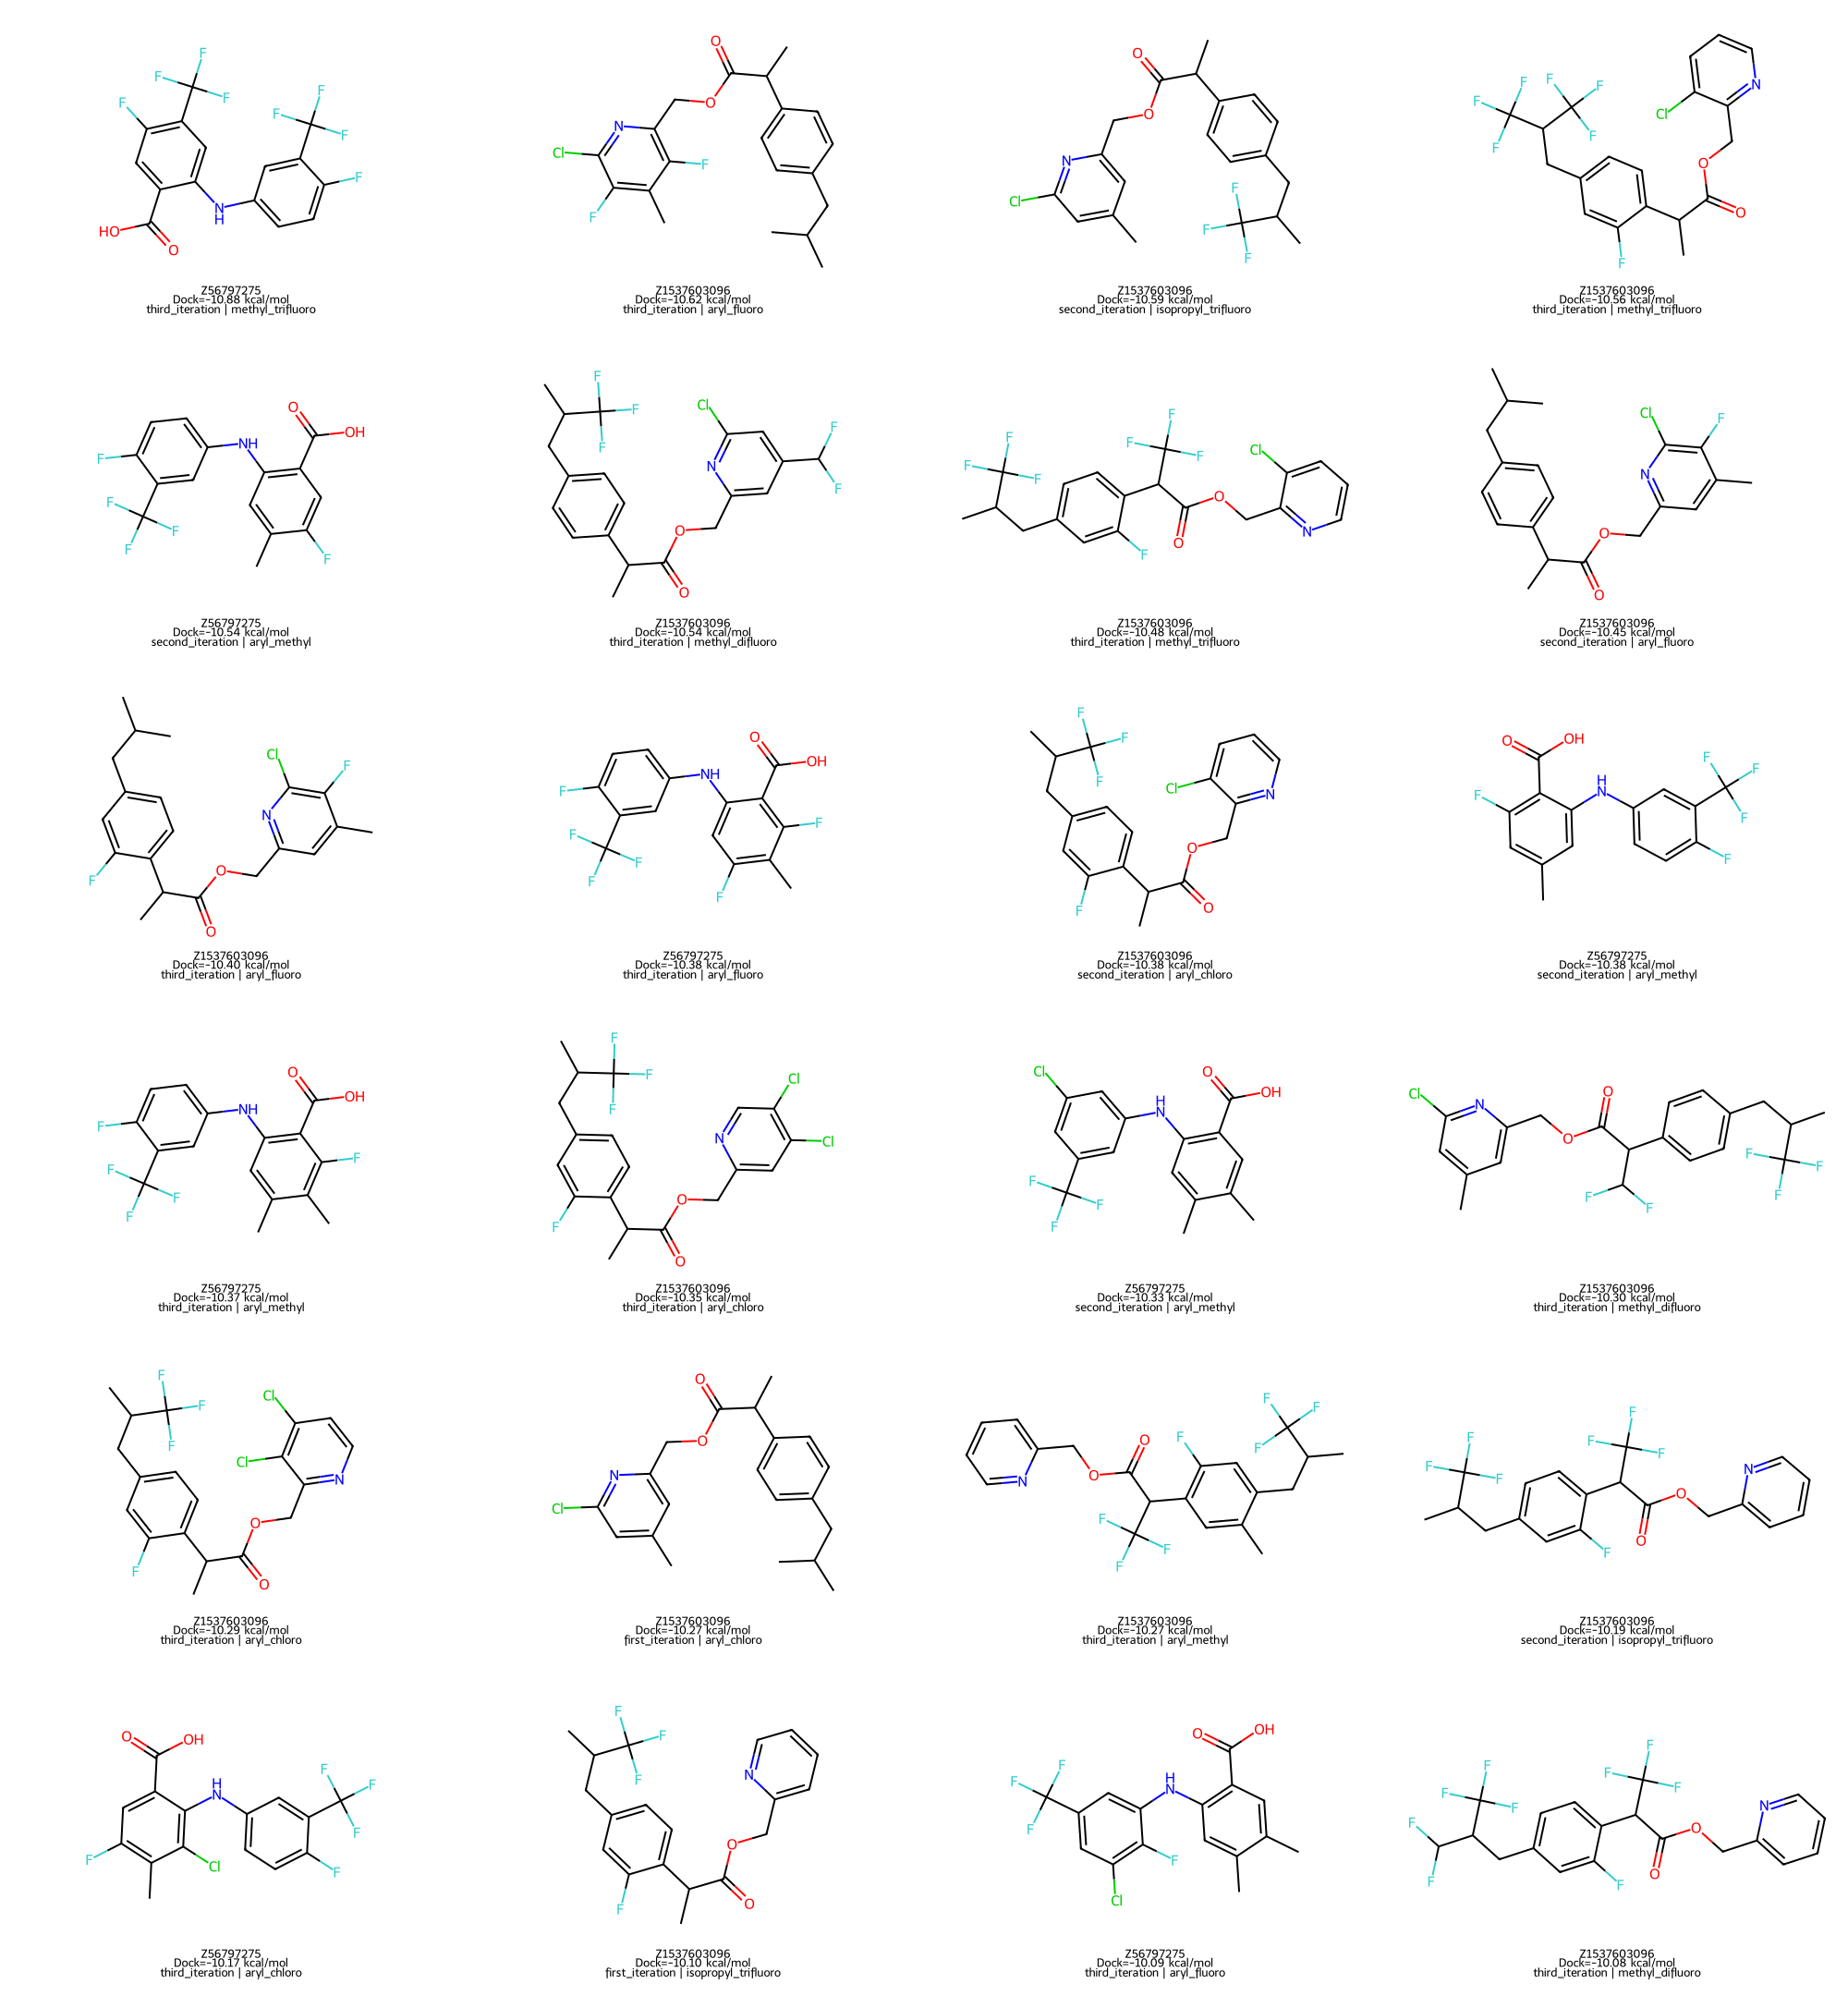

In [13]:
RUN_ITERATIVE_ANALOG_LOOP = bool(globals().get('RUN_ITERATIVE_ANALOG_LOOP', False))
if not RUN_ITERATIVE_ANALOG_LOOP:
    print('Skipping optional iterative analog expansion loop. Set RUN_ITERATIVE_ANALOG_LOOP = True in the config cell to enable it.')
else:
    from pathlib import Path
    import numpy as np
    import pandas as pd
    from rdkit import Chem
    from rdkit.Chem import Draw
    from IPython.display import display

    # ============================================================
    # Iterative analog expansion+docking loop (single-cell workflow)
    # - Start from best docked analogs in existing docking output
    # - For each round: take top N by affinity, generate K analogs each,
    #   dock them, keep results, repeat.
    # - Final: visualize best analogs with parent and docking scores.
    # ============================================================

    OUT_DIR = Path("outputs")
    DOCK_DIR = OUT_DIR / "docking"
    DOCK_BEST_CSV = DOCK_DIR / "docking_best_pose_per_ligand.csv"
    SEED_ANALOG_CSV = OUT_DIR / "enamine1123_top5_analogs.csv"

    ITER_OUT_DIR = OUT_DIR / "iterative_analog_docking"
    ITER_OUT_DIR.mkdir(parents=True, exist_ok=True)

    N_ROUNDS = 3
    TOP_PER_ROUND = 10
    ANALOGS_PER_PARENT = 2
    FINAL_SHOW_N = 24
    BASE_SEED = 2026

    # Resolve analog generator from notebook globals, with local fallback for fresh kernels.
    if "generate_structural_analogs" in globals():
        _iter_generate_analogs = generate_structural_analogs
    else:
        from rdkit.Chem import AllChem
        from rdkit.Chem import rdChemReactions

        _FALLBACK_ANALOG_REACTIONS = [
            ("methyl_ester", "[C:1](=[O:2])[O:3][H]>>[C:1](=[O:2])[O:3]C"),
            ("ethyl_ester", "[C:1](=[O:2])[O:3][H]>>[C:1](=[O:2])[O:3]CC"),
            ("n_propyl_ester", "[C:1](=[O:2])[O:3][H]>>[C:1](=[O:2])[O:3]CCC"),
            ("isopropyl_ester", "[C:1](=[O:2])[O:3][H]>>[C:1](=[O:2])[O:3]C(C)C"),
            ("tert_butyl_ester", "[C:1](=[O:2])[O:3][H]>>[C:1](=[O:2])[O:3]C(C)(C)C"),
            ("n_methyl", "[N:1][H]>>[N:1]C"),
            ("o_methyl", "[O:1][H]>>[O:1]C"),
            ("aryl_methyl", "[cH:1]>>[c:1]C"),
            ("aryl_chloro", "[cH:1]>>[c:1]Cl"),
            ("aryl_fluoro", "[cH:1]>>[c:1]F"),
            ("methyl_monofluoro", "[CH3:1]>>[CH2:1]F"),
            ("methyl_difluoro", "[CH3:1]>>[CH:1](F)F"),
            ("methyl_trifluoro", "[CH3:1]>>[C:1](F)(F)F"),
            ("ethyl_monofluoro", "[CH2:1][CH3:2]>>[CH2:1][CH2:2]F"),
            ("ethyl_difluoro", "[CH2:1][CH3:2]>>[CH2:1][CH:2](F)F"),
            ("ethyl_trifluoro", "[CH2:1][CH3:2]>>[CH2:1][C:2](F)(F)F"),
            ("isopropyl_monofluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[CH2:3]F"),
            ("isopropyl_difluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[CH:3](F)F"),
            ("isopropyl_trifluoro", "[CH:1]([CH3:2])[CH3:3]>>[CH:1]([CH3:2])[C:3](F)(F)F"),
        ]
        _FALLBACK_RXNS = [(n, rdChemReactions.ReactionFromSmarts(s)) for n, s in _FALLBACK_ANALOG_REACTIONS]

        def _iter_generate_analogs(parent_smiles: str, n: int, seed: int) -> list[dict]:
            mol = Chem.MolFromSmiles(str(parent_smiles).strip())
            if mol is None:
                return []

            rng = np.random.default_rng(seed)
            out, seen = [], set()
            order = list(range(len(_FALLBACK_RXNS)))
            rng.shuffle(order)

            for idx in order:
                name, rxn = _FALLBACK_RXNS[idx]
                if rxn is None:
                    continue
                try:
                    prods = rxn.RunReactants((mol,))
                except Exception:
                    continue
                for prod_set in prods:
                    if not prod_set:
                        continue
                    p = prod_set[0]
                    try:
                        Chem.SanitizeMol(p)
                    except Exception:
                        continue
                    smi = Chem.MolToSmiles(p, isomericSmiles=True)
                    if smi in seen:
                        continue
                    seen.add(smi)
                    out.append({"smiles": smi, "transform": name})
                    if len(out) >= n:
                        return out

            # Fallback fill: randomized SMILES views if reactions yield too little
            if len(out) < n:
                can = Chem.MolToSmiles(mol, isomericSmiles=True)
                if can not in seen:
                    out.append({"smiles": can, "transform": "parent_fallback"})
                    seen.add(can)
                tries = 0
                while len(out) < n and tries < 24:
                    tries += 1
                    rs = Chem.MolToSmiles(mol, isomericSmiles=True, doRandom=True)
                    if rs in seen:
                        continue
                    seen.add(rs)
                    out.append({"smiles": rs, "transform": "fallback_randomized_smiles"})

            return out[:n]

    if "submit_and_poll" not in globals() or "flatten_results" not in globals():
        raise RuntimeError("Run the docking cell first (missing submit_and_poll/flatten_results).")

    if not DOCK_BEST_CSV.exists():
        raise FileNotFoundError(f"Missing {DOCK_BEST_CSV.resolve()}; run docking first.")
    if not SEED_ANALOG_CSV.exists():
        raise FileNotFoundError(f"Missing {SEED_ANALOG_CSV.resolve()}; run analog generation first.")

    seed_analog = pd.read_csv(SEED_ANALOG_CSV)
    dock_best = pd.read_csv(DOCK_BEST_CSV)

    # Map Enamine catalog IDs (parent_name) to human-readable drug names from enrichment output.
    ENRICHED_ITER_CSV = OUT_DIR / "enamine1123_final_compounds_enriched.csv"

    def _iter_build_parent_display_lookup(path: Path) -> dict[str, str]:
        lookup: dict[str, str] = {}
        if not path.exists():
            return lookup
        try:
            e = pd.read_csv(path)
        except Exception:
            return lookup
        if "parent_name" not in e.columns:
            return lookup
        for pid, sub in e.groupby(e["parent_name"].astype(str).str.strip(), dropna=False):
            pid_s = str(pid).strip()
            if not pid_s or pid_s.lower() == "nan":
                continue
            disp = ""
            for col in ("parent_display_name", "parent_pubchem_name"):
                if col in sub.columns:
                    s = sub[col].dropna().astype(str).str.strip()
                    s = s[s.ne("") & s.str.lower().ne("nan")]
                    if len(s):
                        disp = s.iloc[0]
                        break
            if disp:
                lookup[pid_s] = disp
        return lookup

    _iter_parent_display_lookup = _iter_build_parent_display_lookup(ENRICHED_ITER_CSV)

    def _iter_parent_display(enamine_id: str) -> str:
        k = str(enamine_id or "").strip()
        if not k:
            return "unknown_parent"
        return _iter_parent_display_lookup.get(k, k)

    if not _iter_parent_display_lookup:
        print(
            f"Note: no parent drug names found ({ENRICHED_ITER_CSV.name} missing or empty). "
            "Run the PubChem enrichment cell first for names like 'Flufenamic acid' instead of catalog IDs."
        )

    if "batch" not in dock_best.columns or "smiles" not in dock_best.columns or "affinity" not in dock_best.columns:
        raise ValueError("docking_best_pose_per_ligand.csv missing required columns: batch/smiles/affinity")

    # Seed pool = already docked top5_analogs entries
    seed_d = dock_best[dock_best["batch"].astype(str).str.strip().eq("top5_analogs")].copy()
    seed_d["smiles"] = seed_d["smiles"].astype(str).str.strip()
    seed_d["affinity"] = pd.to_numeric(seed_d["affinity"], errors="coerce")
    seed_d = seed_d.dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
    seed_d = seed_d.drop_duplicates(subset=["smiles"], keep="first")

    if seed_d.empty:
        raise RuntimeError("No seed analog docking rows found in top5_analogs batch.")

    # Map analog_smiles -> parent_name/transform from initial analog table
    seed_map = seed_analog[[c for c in ["parent_name", "analog_smiles", "analog_transform", "analog_gnn_score"] if c in seed_analog.columns]].copy()
    if "analog_smiles" not in seed_map.columns:
        raise RuntimeError("enamine1123_top5_analogs.csv missing analog_smiles.")
    seed_map["analog_smiles"] = seed_map["analog_smiles"].astype(str).str.strip()

    pool = seed_d.rename(columns={"smiles": "analog_smiles", "affinity": "dock_affinity"}).merge(seed_map, on="analog_smiles", how="left")
    pool["parent_enamine_id"] = pool["parent_name"].astype(str).str.strip()
    pool["parent_display_name"] = pool["parent_enamine_id"].map(_iter_parent_display)
    pool["round"] = 0
    pool["origin_round"] = 0
    pool["source_tag"] = "seed_top5_analogs"

    all_rows = [pool.copy()]
    seen_smiles = set(pool["analog_smiles"].dropna().astype(str).tolist())

    for rnd in range(1, N_ROUNDS + 1):
        parents = pool.sort_values("dock_affinity", ascending=True).head(TOP_PER_ROUND).copy()
        if parents.empty:
            print(f"Round {rnd}: no parent candidates, stopping.")
            break

        gen_rows = []
        for i, row in parents.reset_index(drop=True).iterrows():
            p_smi = str(row.get("analog_smiles", "")).strip()
            if not p_smi:
                continue
            p_name = str(row.get("parent_name", "parent_unknown")).strip() or "parent_unknown"

            analogs = _iter_generate_analogs(p_smi, n=ANALOGS_PER_PARENT, seed=BASE_SEED + rnd * 1000 + i)
            for a_idx, a in enumerate(analogs, start=1):
                s = str(a.get("smiles", "")).strip()
                if not s or s in seen_smiles:
                    continue
                seen_smiles.add(s)
                gen_rows.append(
                    {
                        "round": rnd,
                        "parent_smiles": p_smi,
                        "parent_name": p_name,
                        "parent_enamine_id": p_name,
                        "parent_display_name": _iter_parent_display(p_name),
                        "analog_smiles": s,
                        "analog_transform": str(a.get("transform", "")).strip(),
                        "analog_id": f"r{rnd}_p{i+1}_a{a_idx}",
                    }
                )

        gen_df = pd.DataFrame(gen_rows)
        if gen_df.empty:
            print(f"Round {rnd}: no new analogs generated, stopping.")
            break

        smiles_list = gen_df["analog_smiles"].astype(str).tolist()
        labels = gen_df["analog_id"].astype(str).tolist()
        batch_name = f"iter_r{rnd}"

        print(f"Round {rnd}: docking {len(smiles_list)} new analogs...")
        lig_results = submit_and_poll(smiles_list, labels, batch_name)
        rows = flatten_results(batch_name, lig_results, labels, smiles_list)
        d = pd.DataFrame(rows)
        if d.empty:
            print(f"Round {rnd}: docking returned no rows, stopping.")
            break

        d["affinity"] = pd.to_numeric(d["affinity"], errors="coerce")
        d = d[d["ligand_error"].isna()].dropna(subset=["affinity"]).sort_values("affinity", ascending=True)
        d = d.drop_duplicates(subset=["smiles"], keep="first")
        d = d.rename(columns={"smiles": "analog_smiles", "affinity": "dock_affinity"})

        round_pool = gen_df.merge(d[["analog_smiles", "dock_affinity"]], on="analog_smiles", how="inner")
        round_pool["origin_round"] = rnd
        round_pool["source_tag"] = batch_name

        round_csv = ITER_OUT_DIR / f"round_{rnd}_docked.csv"
        round_pool.to_csv(round_csv, index=False)
        print(f"Round {rnd}: kept {len(round_pool)} docked analogs -> {round_csv}")

        all_rows.append(round_pool.copy())
        pool = round_pool.copy()

    all_df = pd.concat(all_rows, ignore_index=True)

    # Ensure resolved parent drug names on every row (seed + iterative rounds).
    if "parent_enamine_id" not in all_df.columns and "parent_name" in all_df.columns:
        all_df["parent_enamine_id"] = all_df["parent_name"].astype(str).str.strip()
    elif "parent_enamine_id" in all_df.columns:
        all_df["parent_enamine_id"] = all_df["parent_enamine_id"].astype(str).str.strip()
    else:
        all_df["parent_enamine_id"] = ""

    _pid = all_df["parent_enamine_id"].replace({"nan": ""}).astype(str).str.strip()
    _disp = all_df["parent_display_name"].astype(str).str.strip() if "parent_display_name" in all_df.columns else pd.Series([""] * len(all_df), index=all_df.index)
    _disp = _disp.replace({"nan": ""})
    _need = _disp.eq("") | _disp.str.lower().eq("nan")
    all_df["parent_enamine_id"] = _pid
    all_df.loc[_need, "parent_display_name"] = _pid[_need].map(_iter_parent_display)
    all_df.loc[~_need, "parent_display_name"] = _disp[~_need]

    all_df["dock_affinity"] = pd.to_numeric(all_df["dock_affinity"], errors="coerce")
    all_df = all_df.dropna(subset=["dock_affinity"]).sort_values("dock_affinity", ascending=True)
    all_df = all_df.drop_duplicates(subset=["analog_smiles"], keep="first").reset_index(drop=True)

    # Round labels for clear provenance in final output.
    all_df["origin_round"] = pd.to_numeric(all_df.get("origin_round", all_df.get("round", 0)), errors="coerce").fillna(0).astype(int)
    all_df["iteration_label"] = all_df["origin_round"].map(
        lambda x: "original_analog" if int(x) == 0 else ("first_iteration" if int(x) == 1 else ("second_iteration" if int(x) == 2 else ("third_iteration" if int(x) == 3 else f"iteration_{int(x)}")))
    )

    all_csv = ITER_OUT_DIR / "iterative_all_docked.csv"
    all_df.to_csv(all_csv, index=False)

    # FINAL = global-best analogs across ALL rounds (not just latest round).
    best_df = all_df.head(FINAL_SHOW_N).copy()
    best_show_cols = [
        c for c in [
            "parent_display_name",
            "parent_enamine_id",
            "parent_name",
            "analog_smiles",
            "dock_affinity",
            "iteration_label",
            "origin_round",
            "analog_transform",
            "source_tag",
        ] if c in best_df.columns
    ]
    best_table = best_df[best_show_cols].copy()
    best_csv = ITER_OUT_DIR / "iterative_best_final.csv"
    best_table.to_csv(best_csv, index=False)

    print(f"Wrote: {all_csv.resolve()}")
    print(f"Wrote: {best_csv.resolve()}")
    print(f"Total unique docked analogs in iterative run: {len(all_df)}")
    print("\nBest analogs across all rounds:")
    display(best_table)

    # Visualization: global-best analogs + parent + docking + iteration label
    mols, legends = [], []
    for _, r in best_df.iterrows():
        smi = str(r.get("analog_smiles", "")).strip()
        m = Chem.MolFromSmiles(smi) if smi else None
        if m is None:
            continue
        p_disp = str(r.get("parent_display_name", "")).strip() or str(r.get("parent_name", "parent_unknown")).strip()
        p_id = str(r.get("parent_enamine_id", r.get("parent_name", ""))).strip()
        if p_id and p_id != p_disp and p_id.lower() != "nan":
            parent_lines = f"{p_disp}\nEnamine {p_id}"
        else:
            parent_lines = p_disp
        aff = float(r.get("dock_affinity", np.nan))
        tr = str(r.get("analog_transform", ""))
        it = str(r.get("iteration_label", "unknown_iteration"))
        legends.append(f"{parent_lines}\nDock={aff:.2f} kcal/mol\n{it} | {tr}")
        mols.append(m)

    if not mols:
        print("No valid molecules to visualize.")
    else:
        img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(500, 360), legends=legends)
        display(img)
